In [3]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler, LabelEncoder
import json
from math import radians, sin, cos, sqrt, atan2
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from category_encoders import BinaryEncoder

import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS as PanelPooled
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import warnings
warnings.filterwarnings('ignore')

# Overview

In [4]:
data = pd.read_csv('unique_2023-05_2026-01_KL.csv', low_memory=False)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1016117 entries, 0 to 1016116
Data columns (total 54 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   page_id                 822093 non-null   float64
 1   date                    1016117 non-null  object 
 2   contract_type           1016117 non-null  object 
 3   realty_type             1016117 non-null  object 
 4   region                  822093 non-null   object 
 5   city                    1016117 non-null  object 
 6   district                954156 non-null   object 
 7   microdistrict           730119 non-null   object 
 8   street                  742202 non-null   object 
 9   house_number            638361 non-null   object 
 10  latitude                796305 non-null   float64
 11  longitude               796305 non-null   float64
 12  are_coordinates_exact   1016117 non-null  object 
 13  is_near_subway          1016117 non-null  object 
 14  ha

In [6]:
data.describe()

,page_id,latitude,longitude,price,room_count,area_total,area_living,area_kitchen,area_land,floor,floor_count,built_year,ceiling_height,price_uah,price_usd,price_m2_uah,price_m2_usd
count,8.220930e+05,796305.000000,796305.000000,8.220930e+05,1.016117e+06,1.007807e+06,437494.000000,9.594060e+05,28.000000,1.004814e+06,1.004588e+06,508349.000000,559243.000000,1.016117e+06,1.016117e+06,1.007807e+06,1.007807e+06
mean,2.005520e+09,50.273383,28.723468,1.128675e+05,1.855432e+00,3.777834e+05,34.391492,3.967848e+05,2.400000,8.365729e+00,1.483008e+01,1992.124194,2.725757,3.177405e+06,7.870812e+04,4.685459e+04,1.161075e+03
std,1.108683e+09,0.275823,2.907000,3.870860e+05,7.840185e-01,3.791857e+08,276.208884,3.886328e+08,1.756628,6.466412e+00,8.510122e+00,35.325220,0.254997,4.639576e+06,1.152801e+05,5.245060e+04,1.316323e+03
min,3.729535e+08,46.429527,22.575077,1.800000e+01,1.000000e+00,1.000000e+00,1.000000,1.000000e-02,1.000000,1.000000e+00,1.000000e+00,1400.000000,1.750000,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.024135e+09,49.868554,24.062524,1.700000e+04,1.000000e+00,4.400000e+01,19.000000,9.000000e+00,1.500000,3.000000e+00,9.000000e+00,1974.000000,2.500000,3.018416e+04,7.500000e+02,5.142900e+02,1.263000e+01
50%,1.781777e+09,50.415625,30.473451,6.099000e+04,2.000000e+00,5.700000e+01,30.000000,1.400000e+01,1.500000,6.000000e+00,1.200000e+01,2007.000000,2.700000,2.417988e+06,6.000000e+04,4.699170e+04,1.176470e+03
75%,2.964744e+09,50.455774,30.544701,1.090000e+05,2.000000e+00,7.600000e+01,42.400000,1.900000e+01,4.000000,1.200000e+01,2.400000e+01,2017.000000,2.800000,4.217700e+06,1.050000e+05,6.863355e+04,1.700000e+03
max,4.198201e+09,50.783683,36.231856,2.730000e+07,3.000000e+00,3.806630e+11,181917.000000,3.806630e+11,8.000000,1.000000e+02,1.210000e+02,2026.000000,5.000000,7.276698e+08,1.887600e+07,8.427100e+06,2.200000e+05


In [7]:
summary_df = pd.DataFrame({
    'unique_values': data.nunique(),
    'missing_%': data.isnull().mean() * 100
}).sort_values(by='unique_values', ascending=False)

print(summary_df)

                        unique_values  missing_%
update_time                    679782   0.000000
url                            655292   0.000000
page_id                        496206  19.094652
add_time                       492548   0.000000
price_m2_uah                   353515   0.817819
price_uah                       87699   0.000000
price_m2_usd                    83207   0.817819
longitude                       80972  21.632548
latitude                        77527  21.632548
price_usd                       35979   0.000000
price                           17457  19.094652
area_total                       6421   0.817819
house_number                     3524  37.176428
area_kitchen                     2863   5.581149
area_living                      2847  56.944525
street                           2156  26.957033
built_year                        263  49.971411
microdistrict                     131  28.146168
agency                            103  96.994145
floor_count         

In [8]:
for col in data.columns:
    print(f"{col}: nonunique values in {100*data[col].nunique()/len(data)}% of rows")

page_id: nonunique values in 48.833549679810496% of rows
date: nonunique values in 0.0032476575040079046% of rows
contract_type: nonunique values in 0.0001968277275156306% of rows
realty_type: nonunique values in 9.84138637578153e-05% of rows
region: nonunique values in 0.0001968277275156306% of rows
city: nonunique values in 0.0001968277275156306% of rows
district: nonunique values in 0.0014762079563672293% of rows
microdistrict: nonunique values in 0.012892216152273803% of rows
street: nonunique values in 0.21218029026184976% of rows
house_number: nonunique values in 0.34681045588254106% of rows
latitude: nonunique values in 7.629731615552146% of rows
longitude: nonunique values in 7.96876737619782% of rows
are_coordinates_exact: nonunique values in 0.00029524159127344586% of rows
is_near_subway: nonunique values in 0.00029524159127344586% of rows
has_subway_in_radius: nonunique values in 0.0007873109100625224% of rows
price: nonunique values in 1.7180108196201815% of rows
currency: 

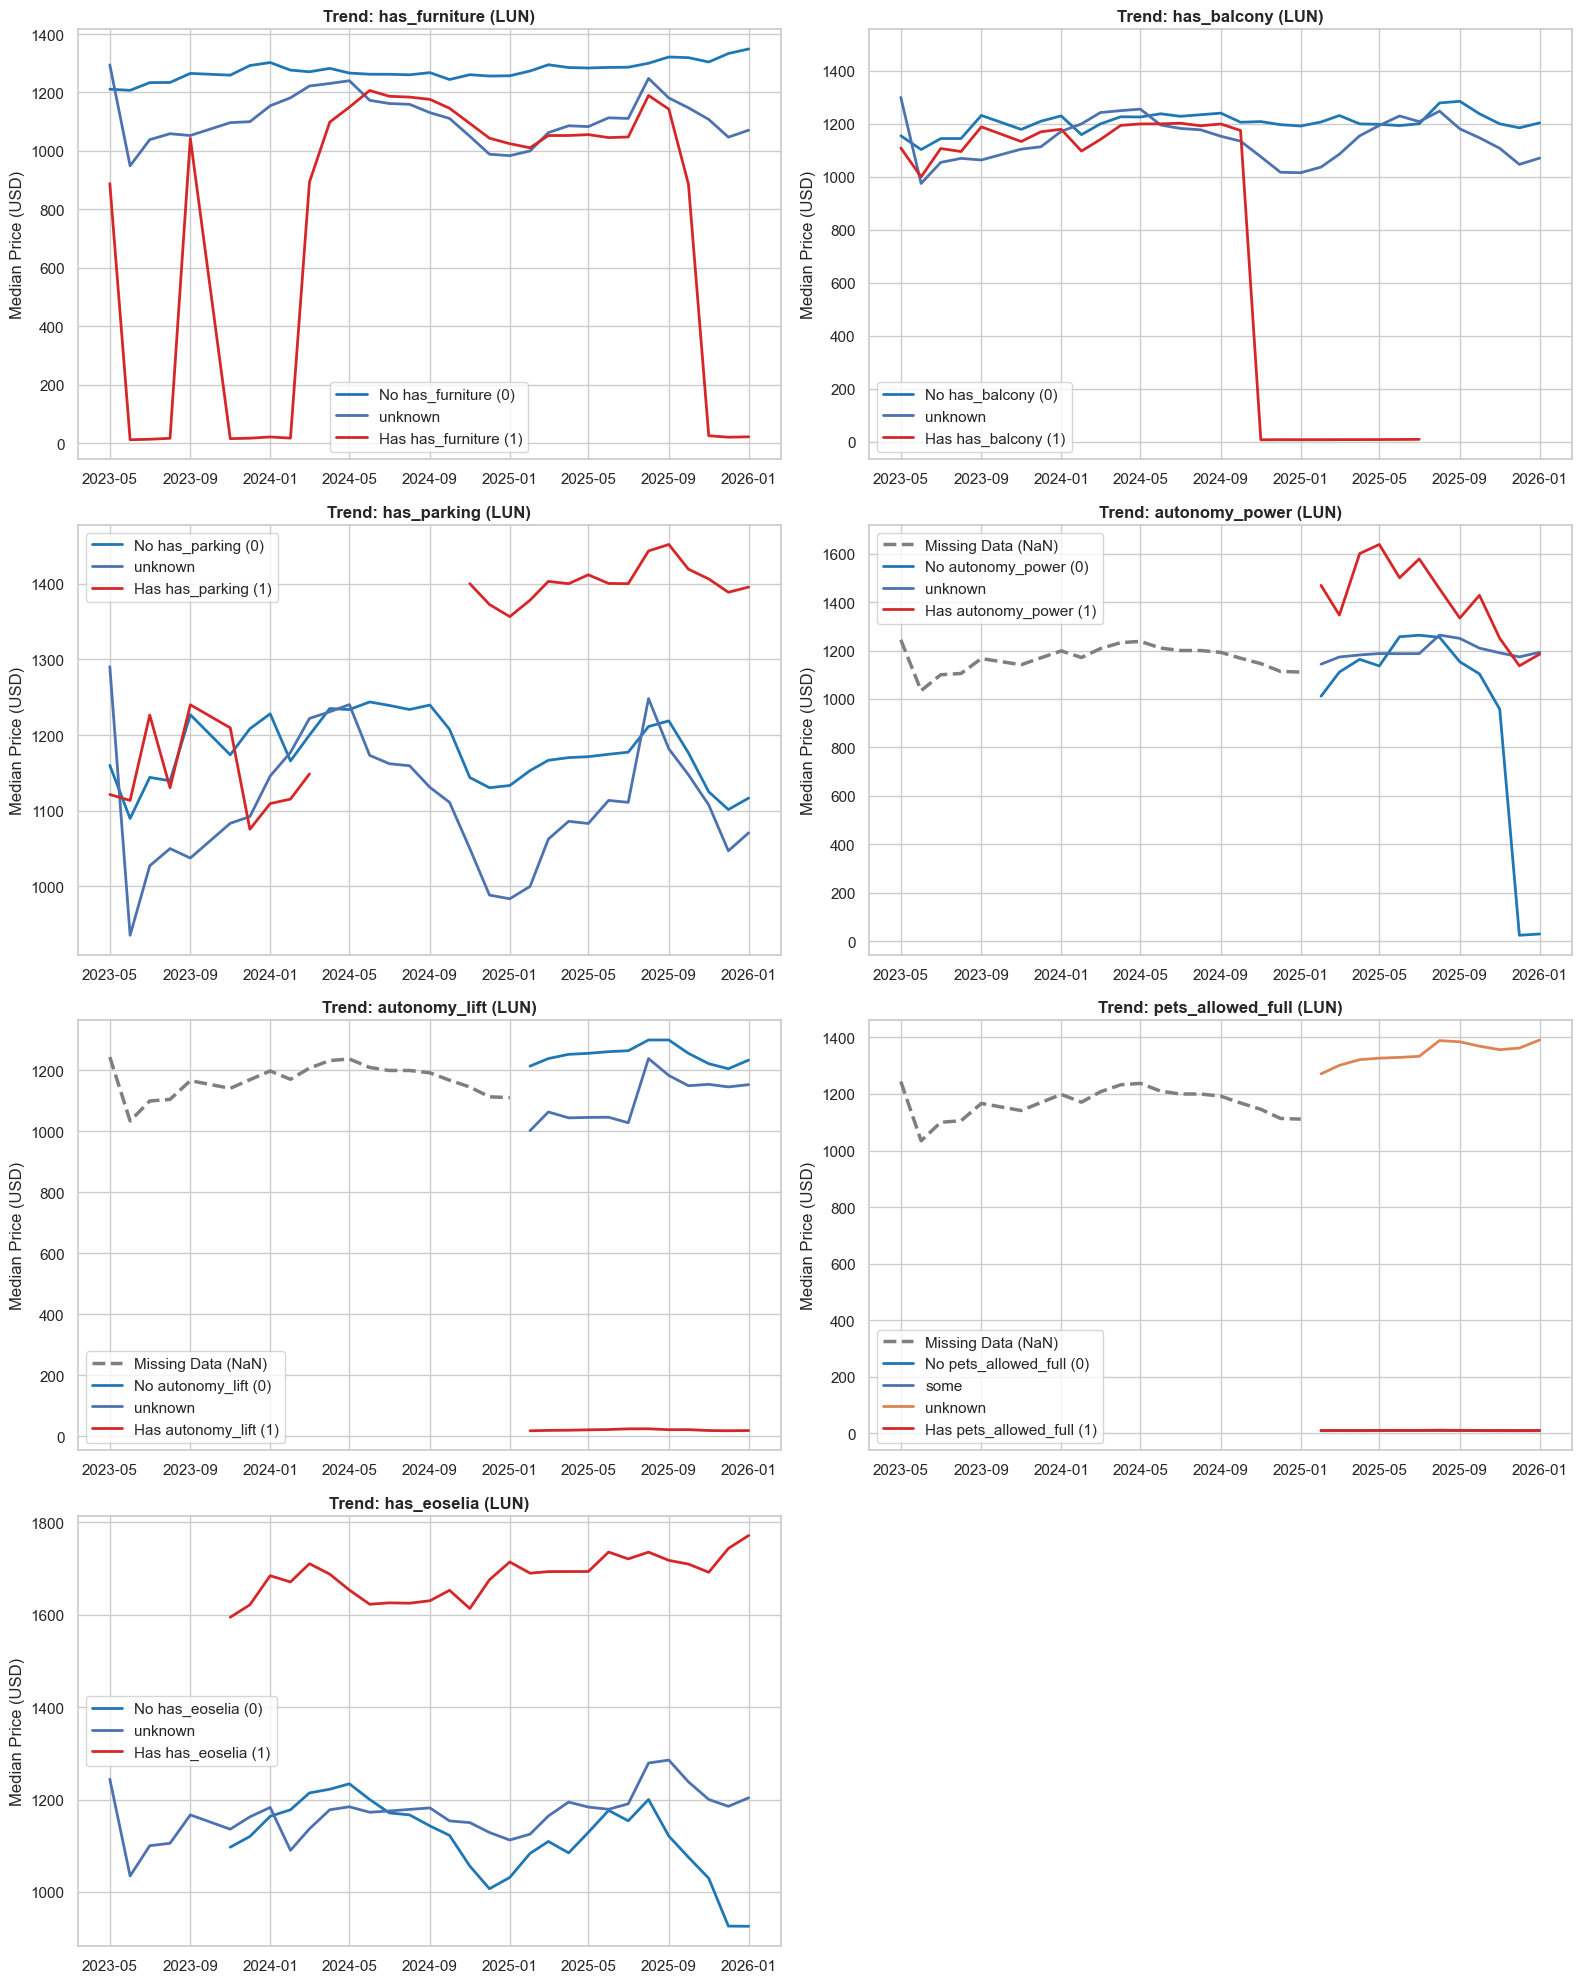

In [9]:
sns.set_theme(style="whitegrid")

def plot_feature_trends(df, dataset_name, features_list):
    valid_features = [f for f in features_list if f in df.columns]
    n_features = len(valid_features)
    
    if n_features == 0:
        print(f"No valid features found for {dataset_name}.")
        return

    rows = math.ceil(n_features / 2)
    fig, axes = plt.subplots(rows, 2, figsize=(16, 5 * rows))
    
    if n_features <= 2:
        axes = np.array(axes).flatten()
    else:
        axes = axes.flatten()
    
    temp_df = df.copy()
    
    if 'month' not in temp_df.columns:
        temp_df['date'] = pd.to_datetime(temp_df['date'])
        temp_df['month'] = temp_df['date'].dt.to_period('M').dt.to_timestamp()
        
    for i, feature in enumerate(valid_features):
        ax = axes[i]
        
        temp_df['plot_category'] = temp_df[feature].astype(str).str.strip().str.lower()
        
        temp_df['plot_category'] = temp_df['plot_category'].replace(['nan', '<na>', 'none', ''], 'missing')
        
        trend = temp_df.groupby(['month', 'plot_category'])['price_m2_usd'].median().unstack()
        
        for category in trend.columns:
            linestyle = '-'
            linewidth = 2
            
            if category in ['1', '1.0', 'yes']:
                color = 'tab:red'
                label = f'Has {feature} (1)'
            elif category in ['0', '0.0', 'no']:
                color = 'tab:blue'
                label = f'No {feature} (0)'
            elif category == 'missing':
                color = 'tab:gray'
                label = 'Missing Data (NaN)'
                linestyle = '--' 
                linewidth = 2.5 
            else:
                color = None
                label = str(category)
                
            ax.plot(trend.index, trend[category], label=label, color=color, 
                    linewidth=linewidth, linestyle=linestyle)
            
        ax.set_title(f'Trend: {feature} ({dataset_name})', fontsize=12, fontweight='bold')
        ax.set_ylabel('Median Price (USD)')
        ax.legend()

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

plot_feature_trends(data, 'LUN', ['has_furniture', 'has_balcony', 'has_parking', 'autonomy_power', 'autonomy_lift', 'pets_allowed_full', 'has_eoselia'])

# Formating 

Update to unifined dates fromats:

In [10]:
data['date'] = pd.to_datetime(data['date']).dt.tz_localize(None)
data['add_time'] = pd.to_datetime(data['add_time']).dt.tz_localize(None)
data['update_time'] = pd.to_datetime(data['update_time'], utc=True).dt.tz_convert(None)

# Add availability of features

In [11]:
def add_global_availability_flags(df, columns_to_check):
    is_nan_df = df[columns_to_check].isna()
    is_nan_df['date'] = df['date']

    is_all_nan_by_date = is_nan_df.groupby('date').all()

    availability_by_date = (~is_all_nan_by_date).astype(int)
    
    missing_features = [col for col in columns_to_check if not availability_by_date[col].all()]
    
    new_columns_list = []
    report_info = {}
    
    if not missing_features:
        print("\n=== GLOBAL STRUCTURAL CHANGES REPORT ===")
        print("All specified features were present across all snapshots (no 100% NaN months found).")
        return df, new_columns_list
        
    unique_patterns = availability_by_date[missing_features].T.drop_duplicates().T
    final_availability_df = pd.DataFrame(index=availability_by_date.index)
    
    for pattern_col in unique_patterns.columns:
        matching_feats = [col for col in missing_features if (availability_by_date[col] == unique_patterns[pattern_col]).all()]

        if len(matching_feats) > 1:
            col_name = "available"
        else:
            col_name = matching_feats[0] + "_available"
            
        final_availability_df[col_name] = unique_patterns[pattern_col]
        new_columns_list.append(col_name)
        
        missing_dates = unique_patterns.index[unique_patterns[pattern_col] == 0].tolist()
        report_info[col_name] = {
            "features": matching_feats,
            "missing_snapshots": missing_dates
        }
        
    df_merged = df.merge(final_availability_df, left_on='date', right_index=True, how='left')
    
    print("\n=== GLOBAL STRUCTURAL CHANGES REPORT (STRICT NaN DETECT) ===")
    for new_col, info in report_info.items():
        print(f"Created flag column: '{new_col}'")
        print(f"Covers features: {', '.join(info['features'])}")
        print(f"DID NOT EXIST (100% NaN) on LUN during these snapshots:")
        for d in info['missing_snapshots']:
            print(f"  - {d}")
        print("-" * 40)
        
    print(f"-> Successfully added {len(new_columns_list)} new column(s): {new_columns_list}")
    
    return df_merged, new_columns_list

columns_to_check = [
            'has_furniture', 
            'has_balcony', 
            'has_parking', 
            'is_owner', 
            'autonomy_power', 
            'autonomy_lift', 
            'pets_allowed_full'
]

data, added_flag_cols = add_global_availability_flags(data, columns_to_check)


=== GLOBAL STRUCTURAL CHANGES REPORT (STRICT NaN DETECT) ===
Created flag column: 'available'
Covers features: autonomy_power, autonomy_lift, pets_allowed_full
DID NOT EXIST (100% NaN) on LUN during these snapshots:
  - 2023-05-25 00:00:00
  - 2023-06-26 00:00:00
  - 2023-07-24 00:00:00
  - 2023-08-23 00:00:00
  - 2023-09-25 00:00:00
  - 2023-11-01 00:00:00
  - 2023-11-24 00:00:00
  - 2023-12-24 00:00:00
  - 2024-01-24 00:00:00
  - 2024-02-24 00:00:00
  - 2024-03-24 00:00:00
  - 2024-04-24 00:00:00
  - 2024-05-24 00:00:00
  - 2024-06-24 00:00:00
  - 2024-07-24 00:00:00
  - 2024-08-24 00:00:00
  - 2024-09-24 00:00:00
  - 2024-10-24 00:00:00
  - 2024-11-26 00:00:00
  - 2024-12-24 00:00:00
  - 2025-01-24 00:00:00
----------------------------------------
-> Successfully added 1 new column(s): ['available']


# Hard cleaning (logical mistakes)

Delete floor > floor_count:

In [12]:
anomalies = data[data['floor'].notna() & 
    data['floor_count'].notna() & 
    (data['floor'] > data['floor_count'])]

print(f"Number of anomaly rows: {len(anomalies)}")

Number of anomaly rows: 1806


In [13]:
to_drop = data[
    data['floor'].notna() & 
    data['floor_count'].notna() & 
    (data['floor'] > data['floor_count'])
].index

data = data.drop(index=to_drop)

print(f"Number of rows after cleaning: {len(data)}")

Number of rows after cleaning: 1014311


Delete rows with unrealistically big floor_count:

In [14]:
lviv_too_high = (data['city'] == 'Львів') & (data['floor_count'] > 30)

kyiv_too_high = (data['city'] == 'Київ') & (data['floor_count'] > 50)

all_anomalies_mask = lviv_too_high | kyiv_too_high

num_to_delete = all_anomalies_mask.sum()
print(f"Number of anomaly rows: {num_to_delete}")

data = data[~all_anomalies_mask]

print(f"Number of rows after cleaning: {len(data)}")

Number of anomaly rows: 92
Number of rows after cleaning: 1014219


Delete rows where area_total too small or too big:

In [15]:
area_anomalies = (data['area_total'] < 5) | (data['area_total'] > 2000)

print(f"Total rows to be removed for area anomalies: {area_anomalies.sum()}")
data = data[~area_anomalies]

Total rows to be removed for area anomalies: 132


Delete rows where area_total < area_living:

In [16]:
area_inconsistency = data[
    data['area_total'].notna() & 
    data['area_living'].notna() & 
    (data['area_total'] < data['area_living'])
].index

print(f"Number of rows (total < living): {len(area_inconsistency)}")

data = data.drop(index=area_inconsistency)

print(f"Dataset length after deleting: {len(data)}")

Number of rows (total < living): 82
Dataset length after deleting: 1014005


Delete rows where area_total < area_living + area_kitchen:

In [17]:
sum_check = data[
    data['area_total'].notna() & 
    data['area_living'].notna() & 
    data['area_kitchen'].notna() &
    (data['area_total'] < (data['area_living'] + data['area_kitchen']))
].index

print(f"Number of rows with area_living + area_kitchen > area_total: {len(sum_check)}")
data = data.drop(index=sum_check)

Number of rows with area_living + area_kitchen > area_total: 963


Delete rows where price, or price_usd or price_uah too small or too big:

In [18]:
sale_mask = (data['contract_type'] == 'продаж') & (
    (data['price_usd'] < 1000) | (data['price_usd'] > 50000000) |
    (data['price_uah'] < 40000) | (data['price_uah'] > 2000000000)
)

rent_mask = (data['contract_type'] == 'оренда') & (
    (data['price_usd'] < 10) | (data['price_usd'] > 50000) |
    (data['price_uah'] < 400) | (data['price_uah'] > 2000000)
)

zero_price_mask = (data['price'] <= 0)

impossible_prices = sale_mask | rent_mask | zero_price_mask

print(f"Deleted rows with imposible prices: {impossible_prices.sum()}")

data = data[~impossible_prices]

Deleted rows with imposible prices: 0


Check the build_year:

In [19]:
data['publish_year'] = data['add_time'].dt.year
time_paradox = data[
    data['built_year'].notna() & 
    data['publish_year'].notna() & 
    (data['built_year'] > data['publish_year'])
].index

print(f"Time paradoxes (built_year > publish_year): {len(time_paradox)}")

data = data.drop(index=time_paradox)

Time paradoxes (built_year > publish_year): 895


Check for logical mistakes in latitude longtitude:

In [20]:
geo_limits = {
    'Київ': {'lat': (50.2, 50.7), 'lon': (30.2, 30.9)},
    'Львів': {'lat': (49.7, 50.0), 'lon': (23.8, 24.2)}
}

geo_errors = []

for city, bounds in geo_limits.items():
    invalid = data[
        (data['city'] == city) & 
        (data['latitude'].notna()) & (data['longitude'].notna()) &
        ((data['latitude'] < bounds['lat'][0]) | (data['latitude'] > bounds['lat'][1]) |
         (data['longitude'] < bounds['lon'][0]) | (data['longitude'] > bounds['lon'][1]))
    ].index
    geo_errors.extend(invalid)

print(f"Number of geographic mistakes (coordinates are not in the city): {len(geo_errors)}")
data = data.drop(index=geo_errors)

Number of geographic mistakes (coordinates are not in the city): 176


In [21]:
print(len(data))

1011971


# Deduplication

In [22]:
print(data.groupby([
    'city', 'contract_type', 'room_count',
    pd.to_datetime(data['date']).dt.to_period('M'),
    data['area_total'].round(-1),
    'floor'
]).size().describe())

count    70661.000000
mean        14.044961
std         23.578058
min          1.000000
25%          1.000000
50%          4.000000
75%         16.000000
max        431.000000
dtype: float64


In [23]:
def preprocess(data):
    data = data.copy()
    
    data['_filled'] = data.notnull().sum(axis=1)
    data = data.sort_values(['date', '_filled'], ascending=[False, False])
    data = data.reset_index(drop=True)
    
    data['_month'] = pd.to_datetime(data['date']).dt.to_period('M').astype(str)
    data['_area_block'] = data['area_total'].round(-1)
    
    prefixes = ['вул.', 'просп.', 'пр.', 'бул.', 'пров.',
                'площа', 'пл.', 'проспект', 'вулиця', 'бульвар']
    def normalize(s):
        if pd.isna(s):
            return np.nan
        s = str(s).strip().lower()
        for p in prefixes:
            s = s.replace(p, '').strip()
        return s
    
    data['_street_norm'] = data['street'].apply(normalize)
    data['_hn_base'] = data['house_number'].astype(str).str.extract(r'(\d+)')[0]
    
    data['_floor_block']    = data['floor'].fillna(-999)
    data['_area_block']     = data['_area_block'].fillna(-999)
    data['_contract_block'] = data['contract_type'].fillna('unknown')
    data['_room_block']     = data['room_count'].fillna(-999)
    
    return data

def generate_pairs(data):
    
    block_cols = ['city', '_contract_block', '_room_block',
                  '_month', '_area_block', '_floor_block']
    
    cols_needed = block_cols + [
        'region', 'district',
        '_street_norm', '_hn_base',
        'latitude', 'longitude', 'are_coordinates_exact',
        'area_total', 'ceiling_height', 'floor',
        'contract_type', 'room_count',
        'date', '_month', '_filled'
    ]
    
    cols_needed = list(dict.fromkeys(cols_needed))
    
    df = data[cols_needed].copy()
    df['_idx'] = data.index
    
    group_sizes = df.groupby(block_cols, dropna=False).size()
    print(f"  Max group size: {group_sizes.max()}")
    print(f"  Mean group size: {group_sizes.mean():.1f}")
    print(f"  Groups > 100: {(group_sizes > 100).sum()}")
    
    pairs = df.merge(df, on=block_cols, suffixes=('_1', '_2'))
    
    pairs = pairs[pairs['_idx_1'] < pairs['_idx_2']].copy()
    pairs = pairs.reset_index(drop=True)
    
    print(f"  Candidate pairs: {len(pairs):,}")
    return pairs

def classify_building_vec(pairs):
    
    result = pd.Series(['UNKNOWN_SAME_BUILDING'] * len(pairs),
                       index=pairs.index, dtype=str)
    
    both_region = pairs['region_1'].notna() & pairs['region_2'].notna()
    result[both_region & 
           (pairs['region_1'] != pairs['region_2'])] = 'DIFFERENT_BUILDING'
    
    alive = result != 'DIFFERENT_BUILDING'
    
    has_coords = (pairs['latitude_1'].notna()  & pairs['longitude_1'].notna() &
                  pairs['latitude_2'].notna()  & pairs['longitude_2'].notna())
    
    pairs['_dist_m'] = np.nan
    coord_mask = alive & has_coords
    
    if coord_mask.any():
        R = 6371000
        lat1 = np.radians(pairs.loc[coord_mask, 'latitude_1'].values)
        lon1 = np.radians(pairs.loc[coord_mask, 'longitude_1'].values)
        lat2 = np.radians(pairs.loc[coord_mask, 'latitude_2'].values)
        lon2 = np.radians(pairs.loc[coord_mask, 'longitude_2'].values)
        dlat, dlon = lat2-lat1, lon2-lon1
        a = (np.sin(dlat/2)**2 + 
             np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2)
        pairs.loc[coord_mask, '_dist_m'] = (
            R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
        )
    
    exact1 = pairs['are_coordinates_exact_1'].fillna(False) == True
    exact2 = pairs['are_coordinates_exact_2'].fillna(False) == True
    both_exact = exact1 & exact2
    
    thresh_same   = np.where(both_exact, 15,  50)
    thresh_likely = np.where(both_exact, 40, 150)
    dist = pairs['_dist_m'].values
    
    coord_same      = coord_mask & (dist < thresh_same)
    coord_likely    = (coord_mask & 
                       (dist >= thresh_same) & 
                       (dist < thresh_likely))
    coord_different = coord_mask & (dist >= thresh_likely)
    
    both_district = pairs['district_1'].notna() & pairs['district_2'].notna()
    district_diff = (alive & both_district & 
                     (pairs['district_1'] != pairs['district_2']))
    
    result[district_diff & coord_different] = 'DIFFERENT_BUILDING'
    result[district_diff & ~has_coords]     = 'DIFFERENT_BUILDING'
    
    alive = result != 'DIFFERENT_BUILDING'
    
    both_street = (pairs['_street_norm_1'].notna() & 
                   pairs['_street_norm_2'].notna())
    street_same = (both_street & 
                   (pairs['_street_norm_1'] == pairs['_street_norm_2']))
    street_diff = alive & both_street & ~street_same
    
    result[street_diff & coord_different]                        = 'DIFFERENT_BUILDING'
    result[street_diff & ~has_coords]                            = 'DIFFERENT_BUILDING'
    result[street_diff & coord_same & (pairs['_dist_m'] >= 30)] = 'DIFFERENT_BUILDING'
    
    alive = result != 'DIFFERENT_BUILDING'
    
    both_hn = pairs['_hn_base_1'].notna() & pairs['_hn_base_2'].notna()
    hn_same = both_hn & (pairs['_hn_base_1'] == pairs['_hn_base_2'])
    hn_diff = alive & both_hn & ~hn_same
    
    result[hn_diff & ~coord_same] = 'DIFFERENT_BUILDING'
    
    alive = result != 'DIFFERENT_BUILDING'
    
    result[alive & coord_same]             = 'SAME_BUILDING'
    result[alive & street_same & hn_same]  = 'SAME_BUILDING'
    result[alive & street_same & ~both_hn] = 'LIKELY_SAME_BUILDING'
    result[alive & coord_likely & 
           (result == 'UNKNOWN_SAME_BUILDING')] = 'LIKELY_SAME_BUILDING'
    
    pairs['_building'] = result
    return pairs

def classify_apartment_vec(pairs):
    
    result = pd.Series(['UNKNOWN_APARTMENT'] * len(pairs),
                       index=pairs.index, dtype=str)
    
    both_contract = pairs['contract_type_1'].notna() & pairs['contract_type_2'].notna()
    result[both_contract & 
           (pairs['contract_type_1'] != pairs['contract_type_2'])] = 'DIFFERENT_APARTMENT'
    
    both_room = pairs['room_count_1'].notna() & pairs['room_count_2'].notna()
    result[both_room & 
           (pairs['room_count_1'] != pairs['room_count_2'])] = 'DIFFERENT_APARTMENT'
    
    alive = result != 'DIFFERENT_APARTMENT'
    
    both_area = pairs['area_total_1'].notna() & pairs['area_total_2'].notna()
    area_diff = np.abs(pairs['area_total_1'] - pairs['area_total_2'])
    result[alive & both_area & (area_diff > 2.0)] = 'DIFFERENT_APARTMENT'
    
    alive = result != 'DIFFERENT_APARTMENT'
    
    both_floor = pairs['floor_1'].notna() & pairs['floor_2'].notna()
    result[alive & both_floor & 
           (pairs['floor_1'] != pairs['floor_2'])] = 'DIFFERENT_APARTMENT'
    
    alive = result != 'DIFFERENT_APARTMENT'
    
    strong = pd.Series(0, index=pairs.index)
    strong += (alive & both_area  & (area_diff <= 0.5)).astype(int)
    strong += (alive & both_floor & 
               (pairs['floor_1'] == pairs['floor_2'])).astype(int)
    
    both_ceil = pairs['ceiling_height_1'].notna() & pairs['ceiling_height_2'].notna()
    ceil_diff = np.abs(pairs['ceiling_height_1'] - pairs['ceiling_height_2'])
    strong += (alive & both_ceil & (ceil_diff < 0.1)).astype(int)
    
    result[alive & (strong >= 2)] = 'SAME_APARTMENT'
    
    pairs['_apartment'] = result
    return pairs

def apply_removal_decision(pairs):
    
    pairs['_remove'] = (
        (pairs['_building']  == 'SAME_BUILDING') &
        (pairs['_apartment'] == 'SAME_APARTMENT')

    )
    return pairs

def deduplicate(data):
    
    print(f"Input rows: {len(data):,}")
    
    print("\n[1/5] Preprocessing...")
    data = preprocess(data)
    
    print("\n[2/5] Generating candidate pairs...")
    pairs = generate_pairs(data)
    
    print("\n[3/5] Classifying buildings...")
    pairs = classify_building_vec(pairs)
    building_counts = pairs['_building'].value_counts()
    print(f"  {building_counts.to_dict()}")
    
    pairs = pairs[pairs['_building'] != 'DIFFERENT_BUILDING'].copy()
    print(f"  Pairs after building filter: {len(pairs):,}")
    
    print("\n[4/5] Classifying apartments...")
    pairs = classify_apartment_vec(pairs)
    print(f"  {pairs['_apartment'].value_counts().to_dict()}")
    
    print("\n[5/5] Applying removal decisions...")
    pairs = apply_removal_decision(pairs)
    
    to_remove = set(pairs.loc[pairs['_remove'], '_idx_2'].tolist())
    print(f"  Rows to remove: {len(to_remove):,}")
    
    temp_cols = [c for c in data.columns if c.startswith('_')]
    data_clean = (data[~data.index.isin(to_remove)]
                  .drop(columns=temp_cols)
                  .reset_index(drop=True))
    
    print(f"\nBefore: {len(data):,}")
    print(f"After:  {len(data_clean):,}")
    print(f"Removed: {len(data)-len(data_clean):,} "
          f"({(len(data)-len(data_clean))/len(data)*100:.1f}%)")
    
    return data_clean

data = deduplicate(data)

Input rows: 1,011,971

[1/5] Preprocessing...

[2/5] Generating candidate pairs...
  Max group size: 431
  Mean group size: 14.1
  Groups > 100: 1097
  Candidate pairs: 27,152,013

[3/5] Classifying buildings...
  {'DIFFERENT_BUILDING': 24530233, 'UNKNOWN_SAME_BUILDING': 2387511, 'SAME_BUILDING': 139853, 'LIKELY_SAME_BUILDING': 94416}
  Pairs after building filter: 2,621,780

[4/5] Classifying apartments...
  {'DIFFERENT_APARTMENT': 1372793, 'UNKNOWN_APARTMENT': 795979, 'SAME_APARTMENT': 453008}

[5/5] Applying removal decisions...
  Rows to remove: 57,482

Before: 1,011,971
After:  954,489
Removed: 57,482 (5.7%)


# Outliers 

In [24]:
cols_check = ['price_usd', 'price_uah', 'area_total', 'floor', 
              'floor_count', 'room_count', 'built_year', 'ceiling_height',
              'price_m2_usd']

for contract in ['Продаж', 'Оренда']:
    print(f"\n{'='*60}")
    print(f"{contract}")
    print('='*60)
    df_sub = data[data['contract_type'] == contract]
    print(df_sub[cols_check].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))


Продаж
          price_usd     price_uah     area_total          floor  \
count  6.334520e+05  6.334520e+05  631094.000000  626540.000000   
mean   1.170160e+05  4.727460e+06      64.689830       8.750512   
std    1.248190e+05  5.019107e+06      29.023494       6.646107   
min    1.050000e+02  4.000000e+03       5.000000       1.000000   
1%     2.480000e+04  9.646750e+05      22.000000       1.000000   
5%     3.700000e+04  1.474315e+06      31.000000       1.000000   
25%    5.990000e+04  2.389770e+06      44.600000       3.000000   
50%    8.500000e+04  3.431554e+06      60.000000       7.000000   
75%    1.350000e+05  5.413993e+06      78.000000      13.000000   
95%    2.998000e+05  1.210315e+07     116.260000      22.000000   
99%    5.400000e+05  2.180489e+07     155.000000      26.000000   
max    1.887600e+07  7.276698e+08    1764.000000      45.000000   

         floor_count     room_count     built_year  ceiling_height  \
count  626848.000000  633452.000000  307678.000000

In [25]:
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

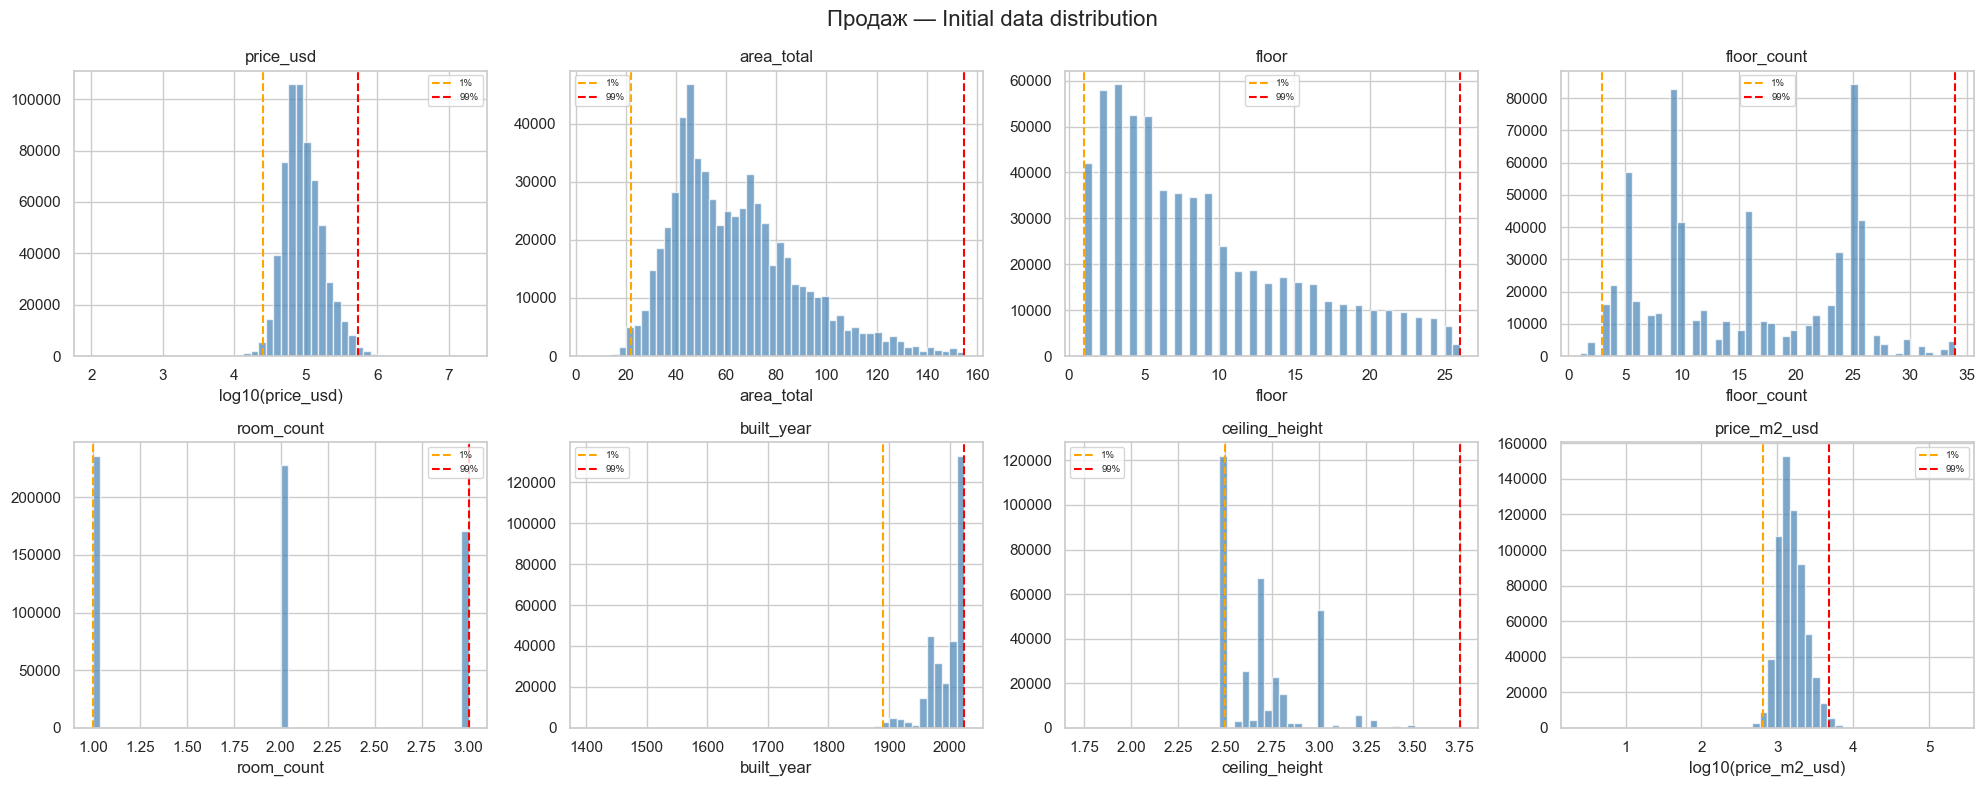

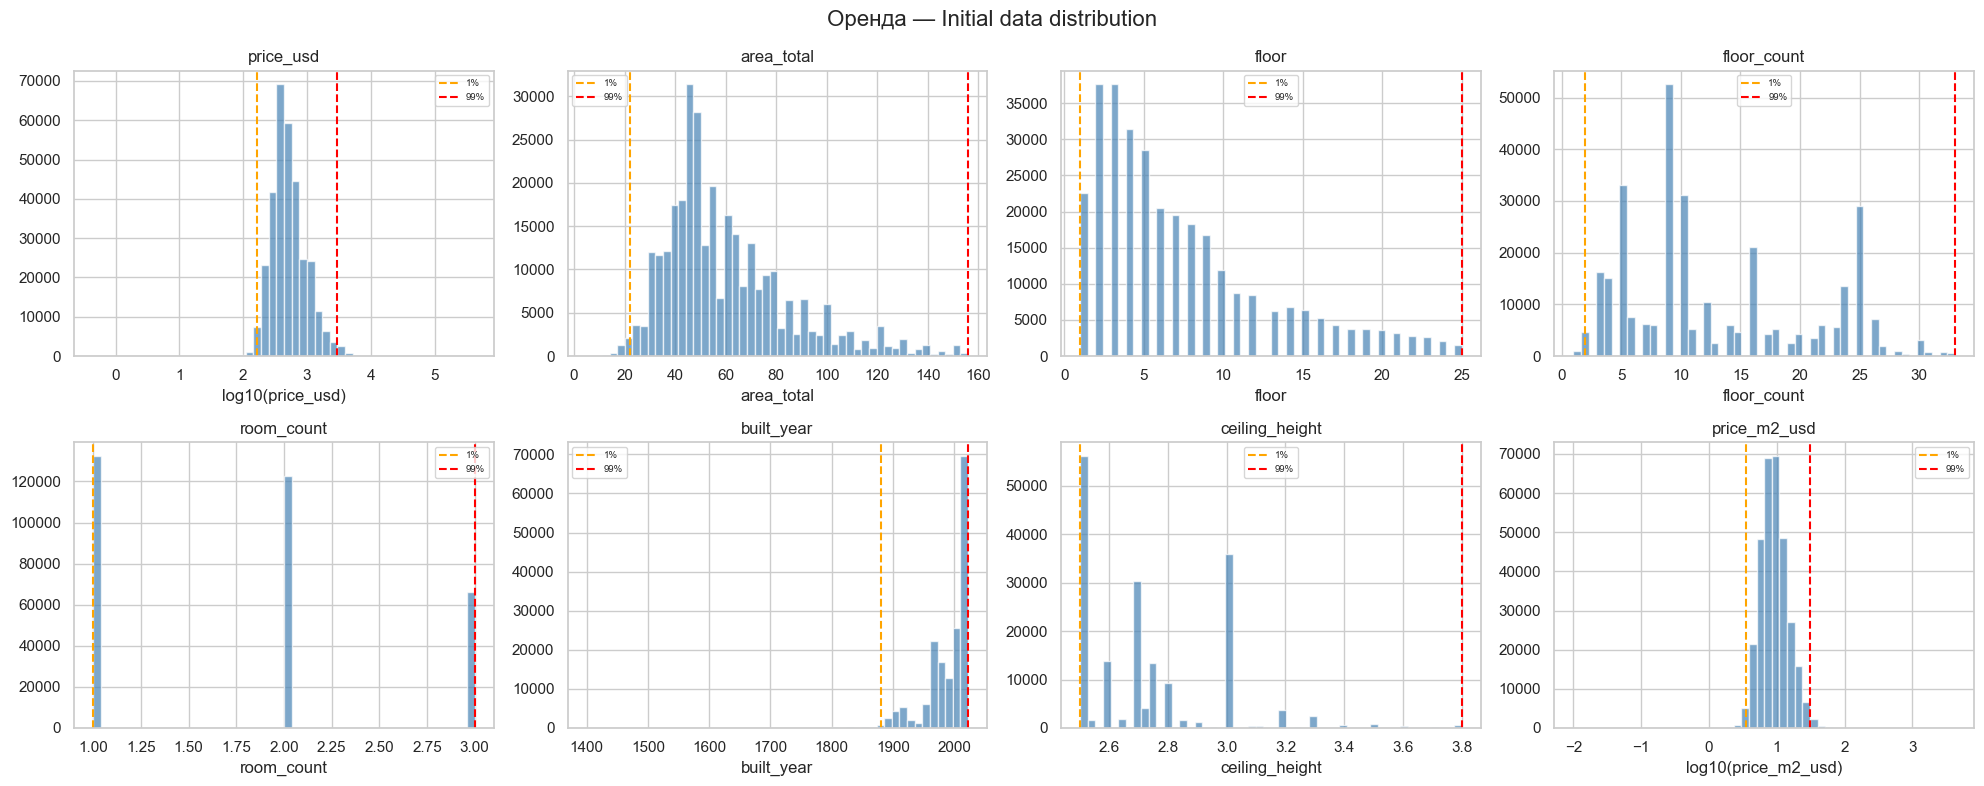

In [26]:
cols_dist = ['price_usd', 'area_total', 'floor', 'floor_count', 
             'room_count', 'built_year', 'ceiling_height', 'price_m2_usd']

for contract in ['Продаж', 'Оренда']:
    df_sub = data[data['contract_type'] == contract].copy()
    n_cols = 4
    n_rows = (len(cols_dist) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    axes = axes.flatten()
    fig.suptitle(f'{contract} — Initial data distribution', fontsize=16)

    for i, col in enumerate(cols_dist):
        ax = axes[i]
        series = df_sub[col].dropna()
        if len(series) == 0:
            ax.set_visible(False)
            continue
        
        if 'price' in col:
            series_plot = series[series > 0]
            ax.hist(np.log10(series_plot), bins=50, color='steelblue', edgecolor='white', alpha=0.7)
            ax.set_xlabel(f'log10({col})')
        else:
            p99 = series.quantile(0.99)
            series_plot = series[series <= p99]
            ax.hist(series_plot, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
            ax.set_xlabel(col)
        
        ax.set_title(col)
        p01, p99 = series.quantile(0.01), series.quantile(0.99)
        ax.axvline(np.log10(p01) if 'price' in col else p01, color='orange', linestyle='--', label='1%')
        ax.axvline(np.log10(p99) if 'price' in col else p99, color='red', linestyle='--', label='99%')
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

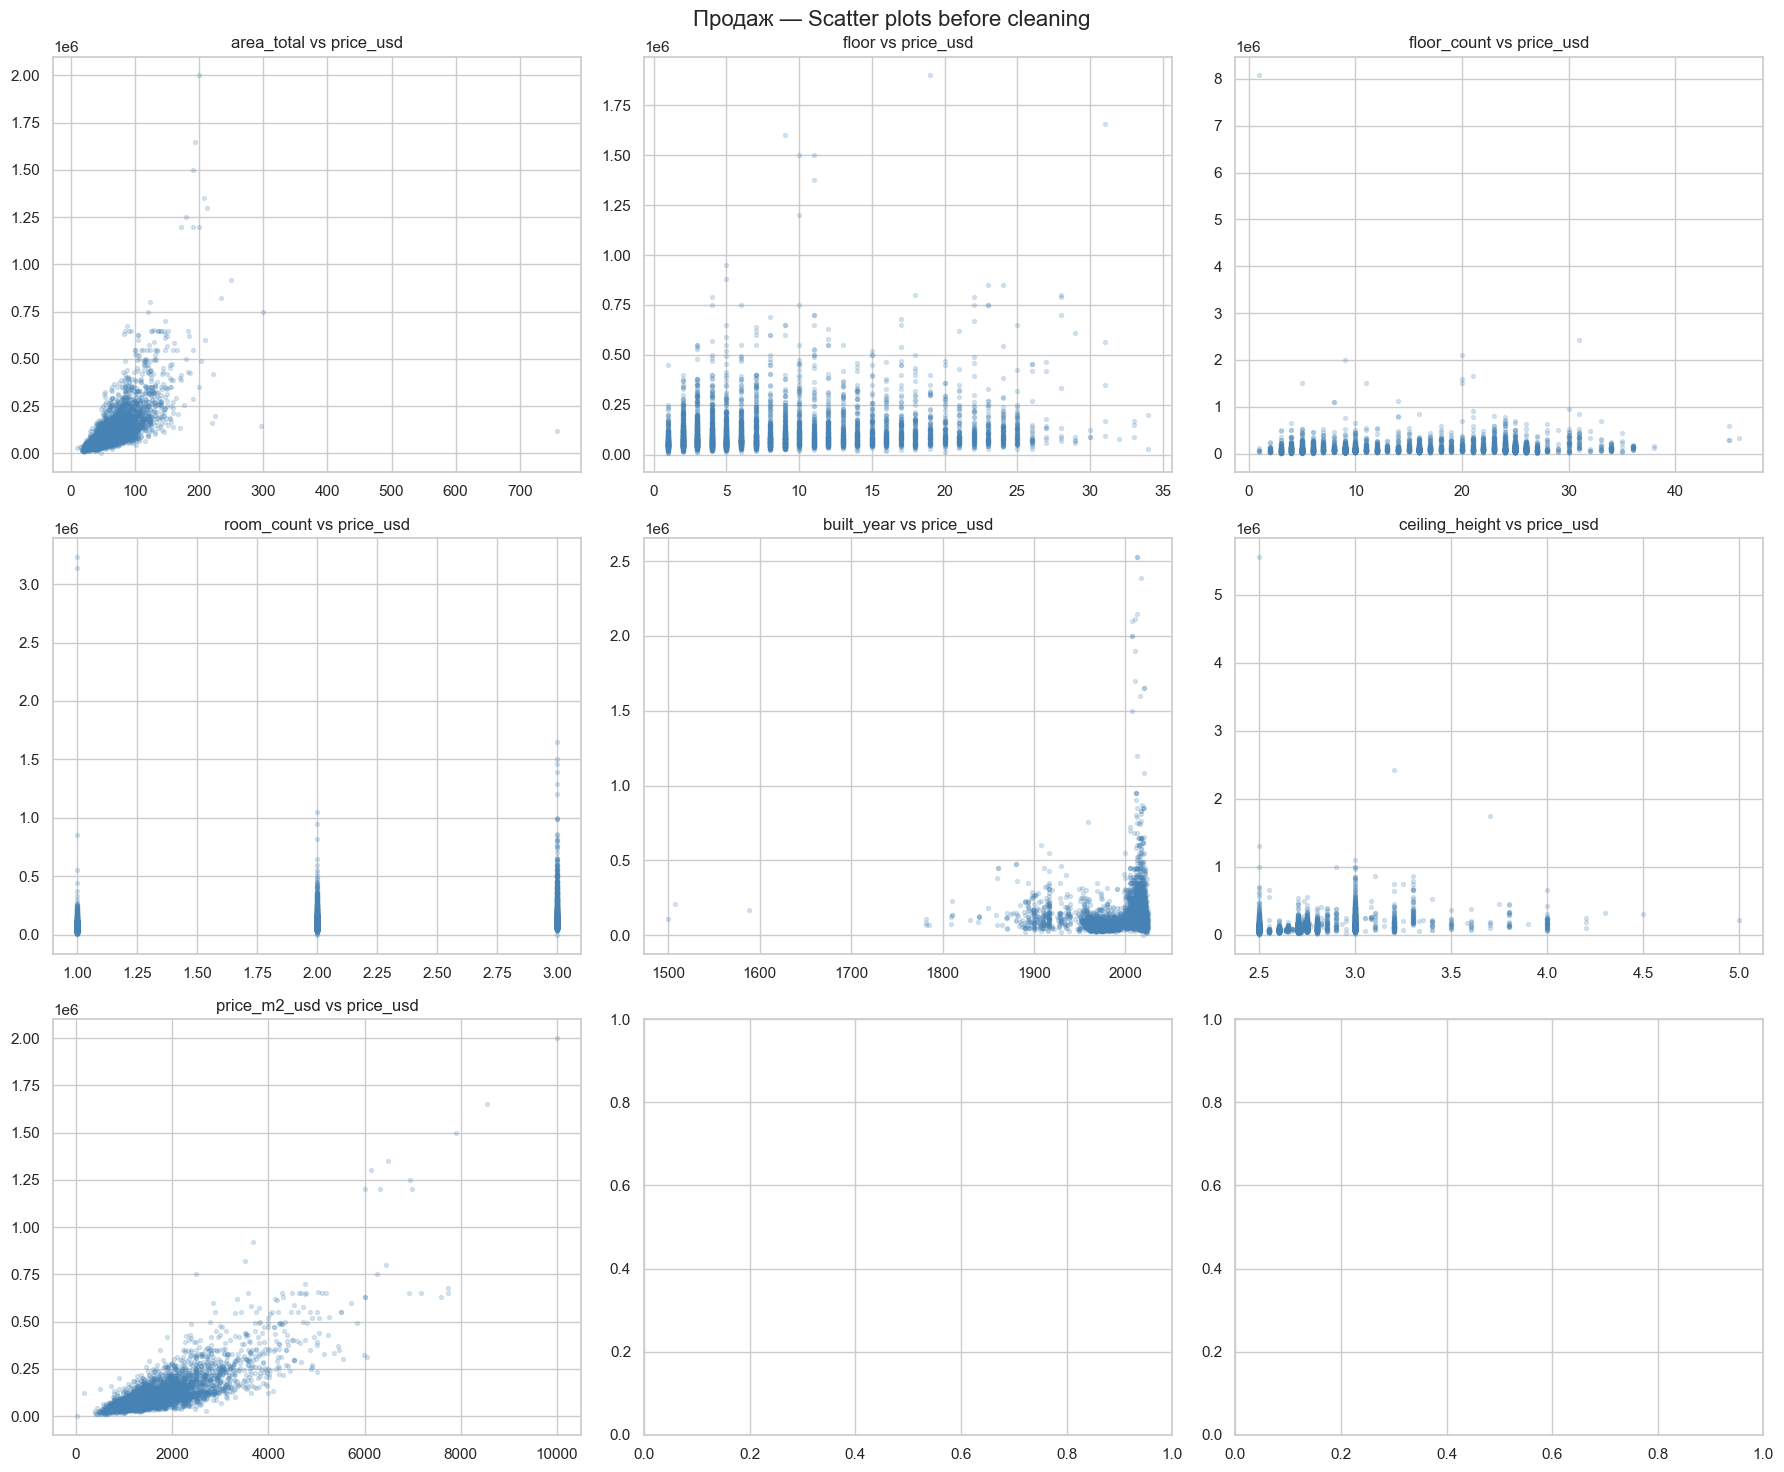

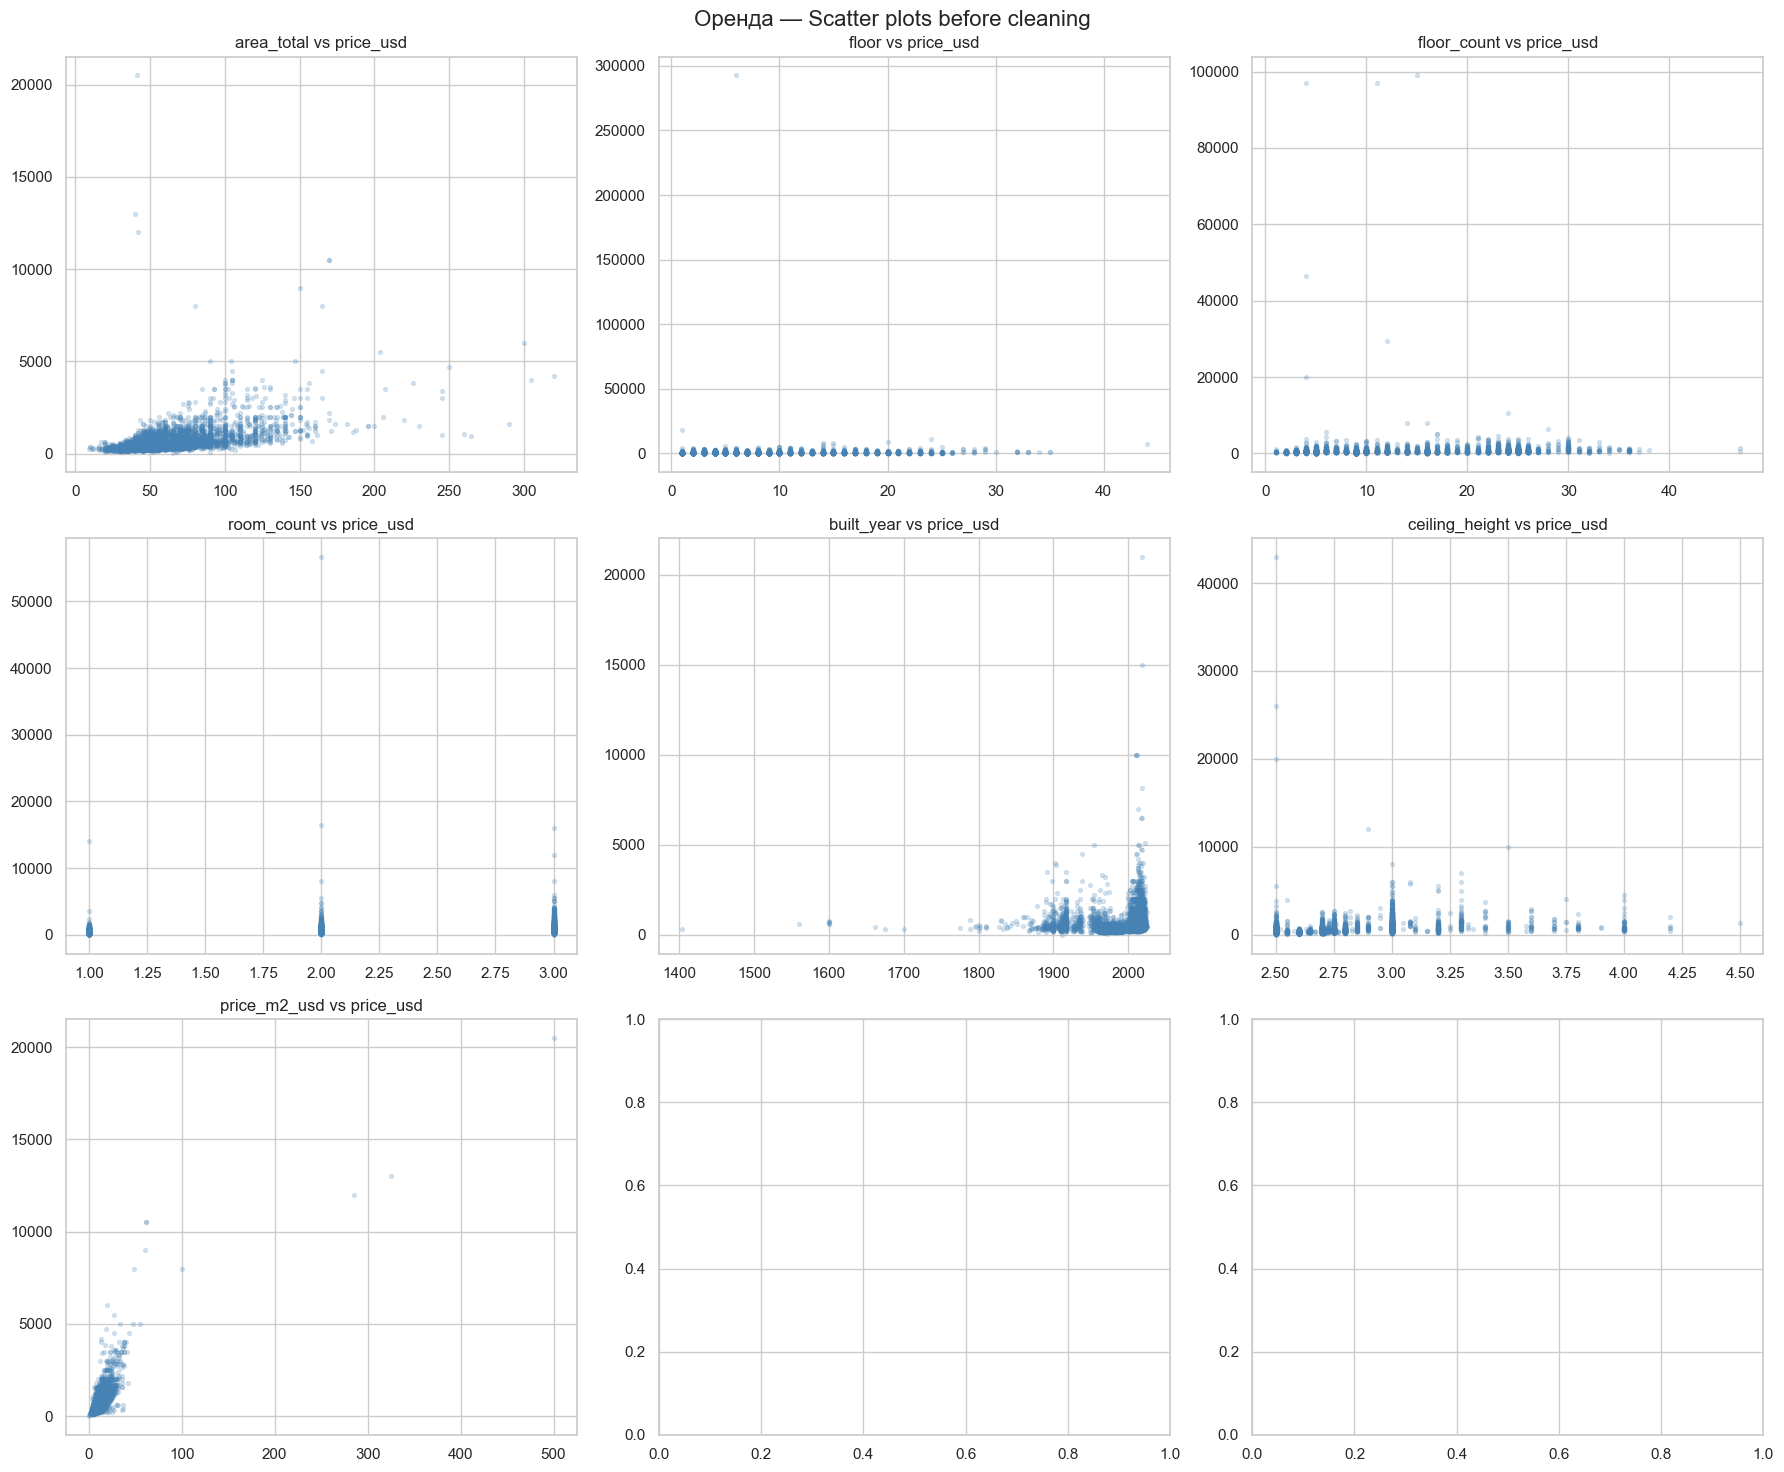

In [27]:
cols_scatter = ['area_total', 'floor', 'floor_count', 'room_count', 'built_year', 'ceiling_height', 'price_m2_usd']

for contract in ['Продаж', 'Оренда']:
    df_sub = data[data['contract_type'] == contract].copy()
    n_rows = (len(cols_scatter) + 2) // 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows * 5))
    axes = axes.flatten()
    fig.suptitle(f'{contract} — Scatter plots before cleaning', fontsize=16)

    for i, col in enumerate(cols_scatter):
        sample_df = df_sub[['price_usd', col]].dropna()
        n_sample = min(5000, len(sample_df))
        if n_sample > 0:
            sample = sample_df.sample(n_sample, random_state=42)
            axes[i].scatter(sample[col], sample['price_usd'], alpha=0.2, s=8, color='steelblue')
            axes[i].set_title(f'{col} vs price_usd')
        else:
            axes[i].set_visible(False)
    plt.tight_layout()
    plt.show()

In [28]:
def remove_real_estate_outliers(df):
    print(f"Rows before cleaning: {len(df)}")
    clean_df = df.copy()

    clean_df = clean_df[(clean_df['area_total'] >= 10) & (clean_df['area_total'] <= 300)]
    print(f"Rows after cleaning: {len(clean_df)}")
    print(f"Deleted anomalies: {len(df) - len(clean_df)}")
    is_kyiv = (clean_df['city'] == 'Київ') & (clean_df['floor'] >= 0) & (clean_df['floor'] <= 50)
    is_lviv = (clean_df['city'] == 'Львів') & (clean_df['floor'] >= 0) & (clean_df['floor'] <= 25)

    clean_df = clean_df[is_kyiv | is_lviv]
    
    print(f"Rows after cleaning: {len(clean_df)}")
    print(f"Deleted anomalies: {len(df) - len(clean_df)}")
    
    clean_df = clean_df[clean_df['ceiling_height'].isna() | ((clean_df['ceiling_height'] >= 2) & (clean_df['ceiling_height'] <= 4.75))]
    print(f"Rows after cleaning: {len(clean_df)}")
    print(f"Deleted anomalies: {len(df) - len(clean_df)}")
    clean_df = clean_df[clean_df['built_year'].isna() | (clean_df['built_year'] >= 1820)]

    print(f"Rows after cleaning: {len(clean_df)}")
    print(f"Deleted anomalies: {len(df) - len(clean_df)}")

    top_10_expensive = clean_df.nlargest(5, 'price_usd')
    clean_df = clean_df.drop(top_10_expensive.index)

    print(f"Rows after cleaning: {len(clean_df)}")
    print(f"Deleted anomalies: {len(df) - len(clean_df)}")
    
    return clean_df

data = remove_real_estate_outliers(data)

Rows before cleaning: 954489
Rows after cleaning: 945945
Deleted anomalies: 8544
Rows after cleaning: 934707
Deleted anomalies: 19782
Rows after cleaning: 934677
Deleted anomalies: 19812
Rows after cleaning: 933407
Deleted anomalies: 21082
Rows after cleaning: 933402
Deleted anomalies: 21087


In [29]:
data = data[data['price_usd'].isna() | (data['price_usd'] <= 8000000)]

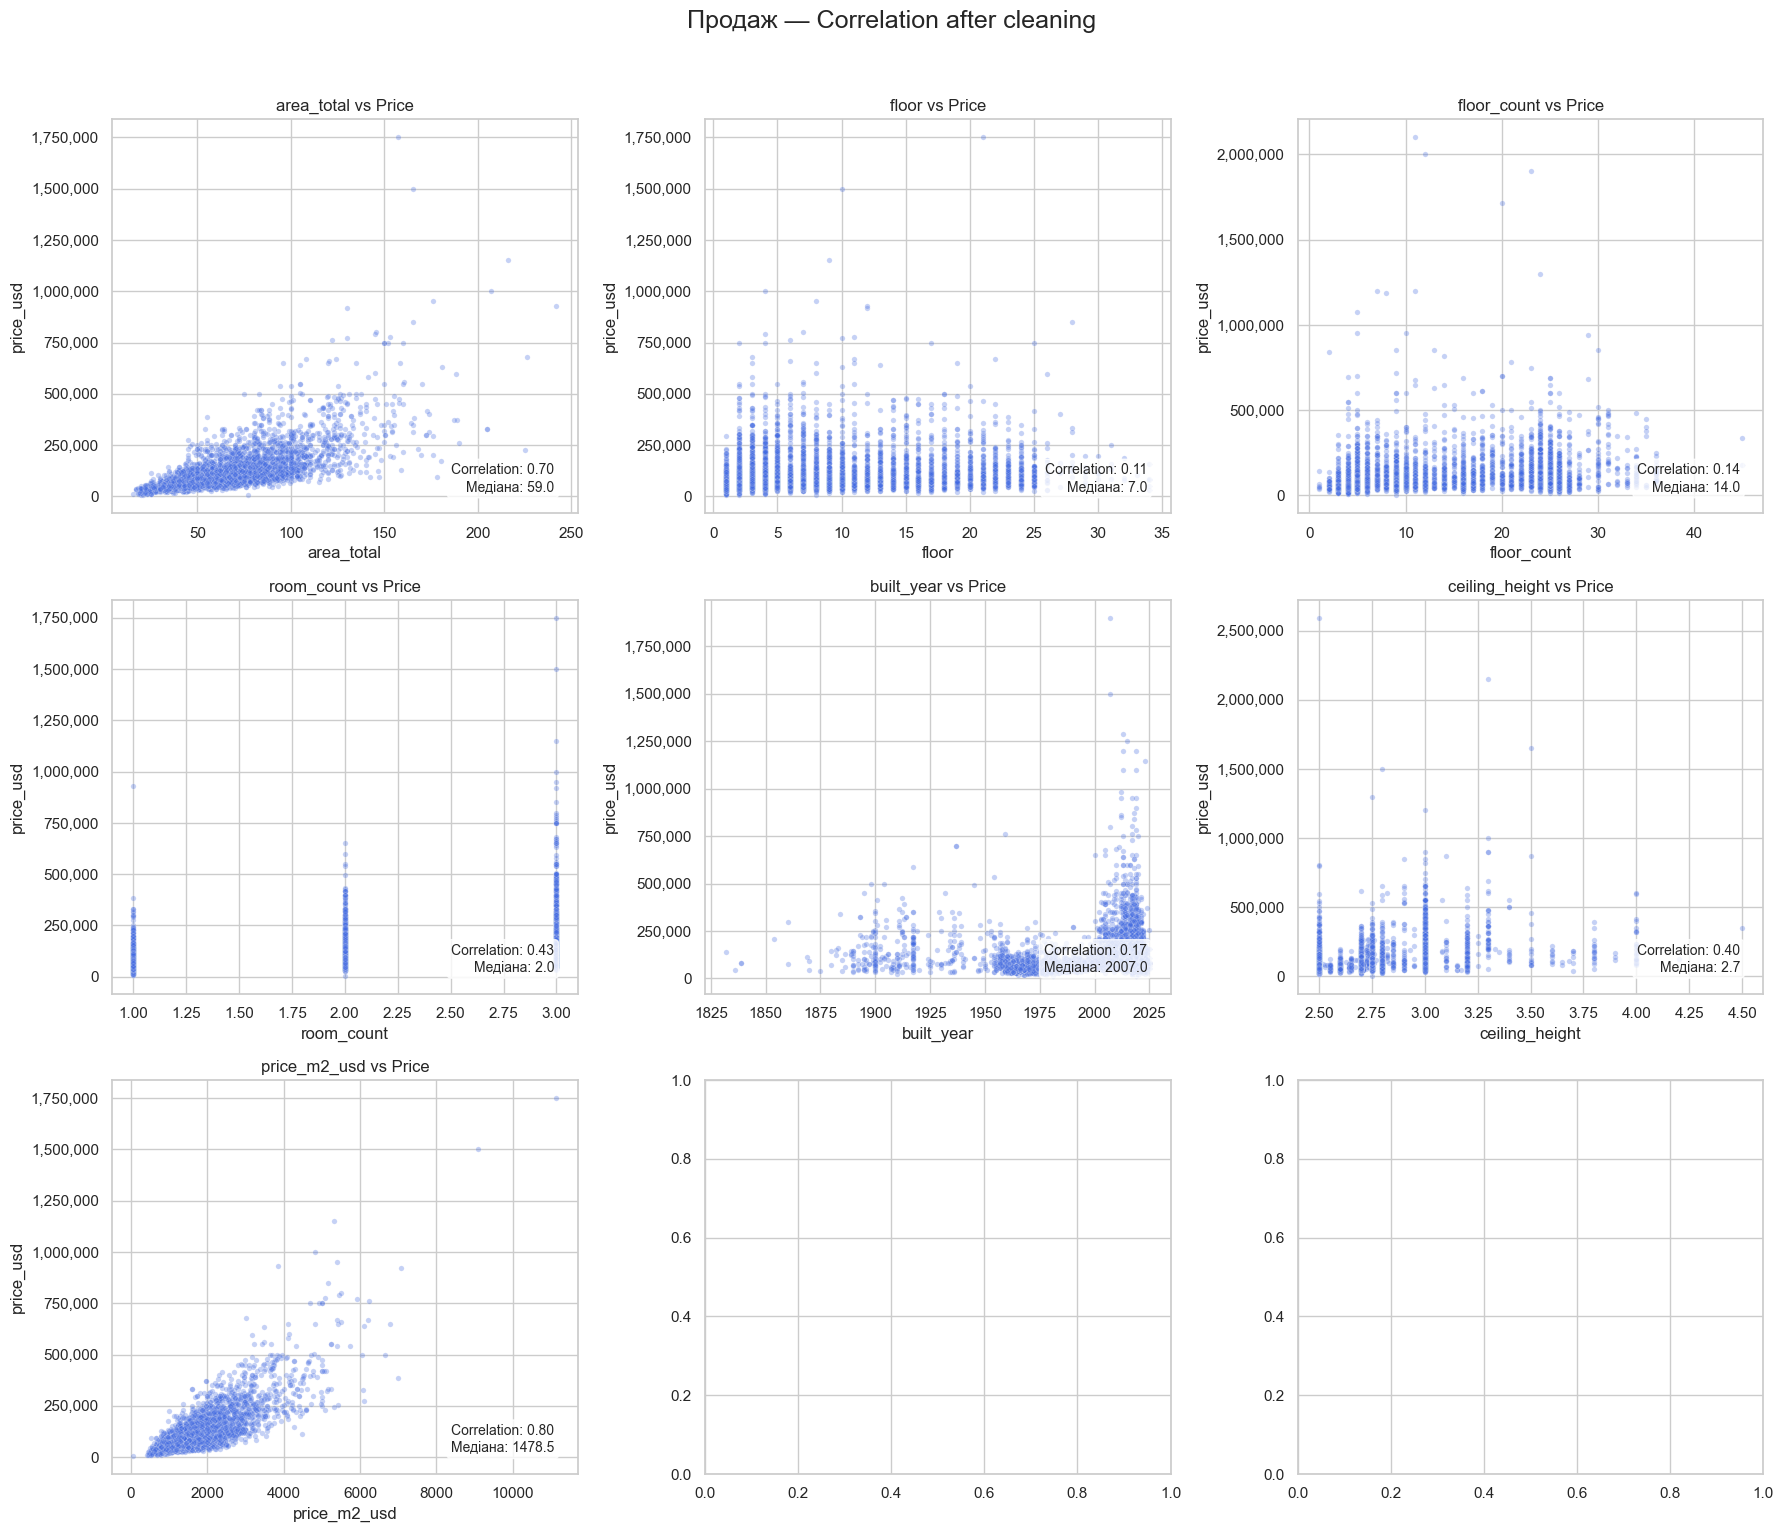

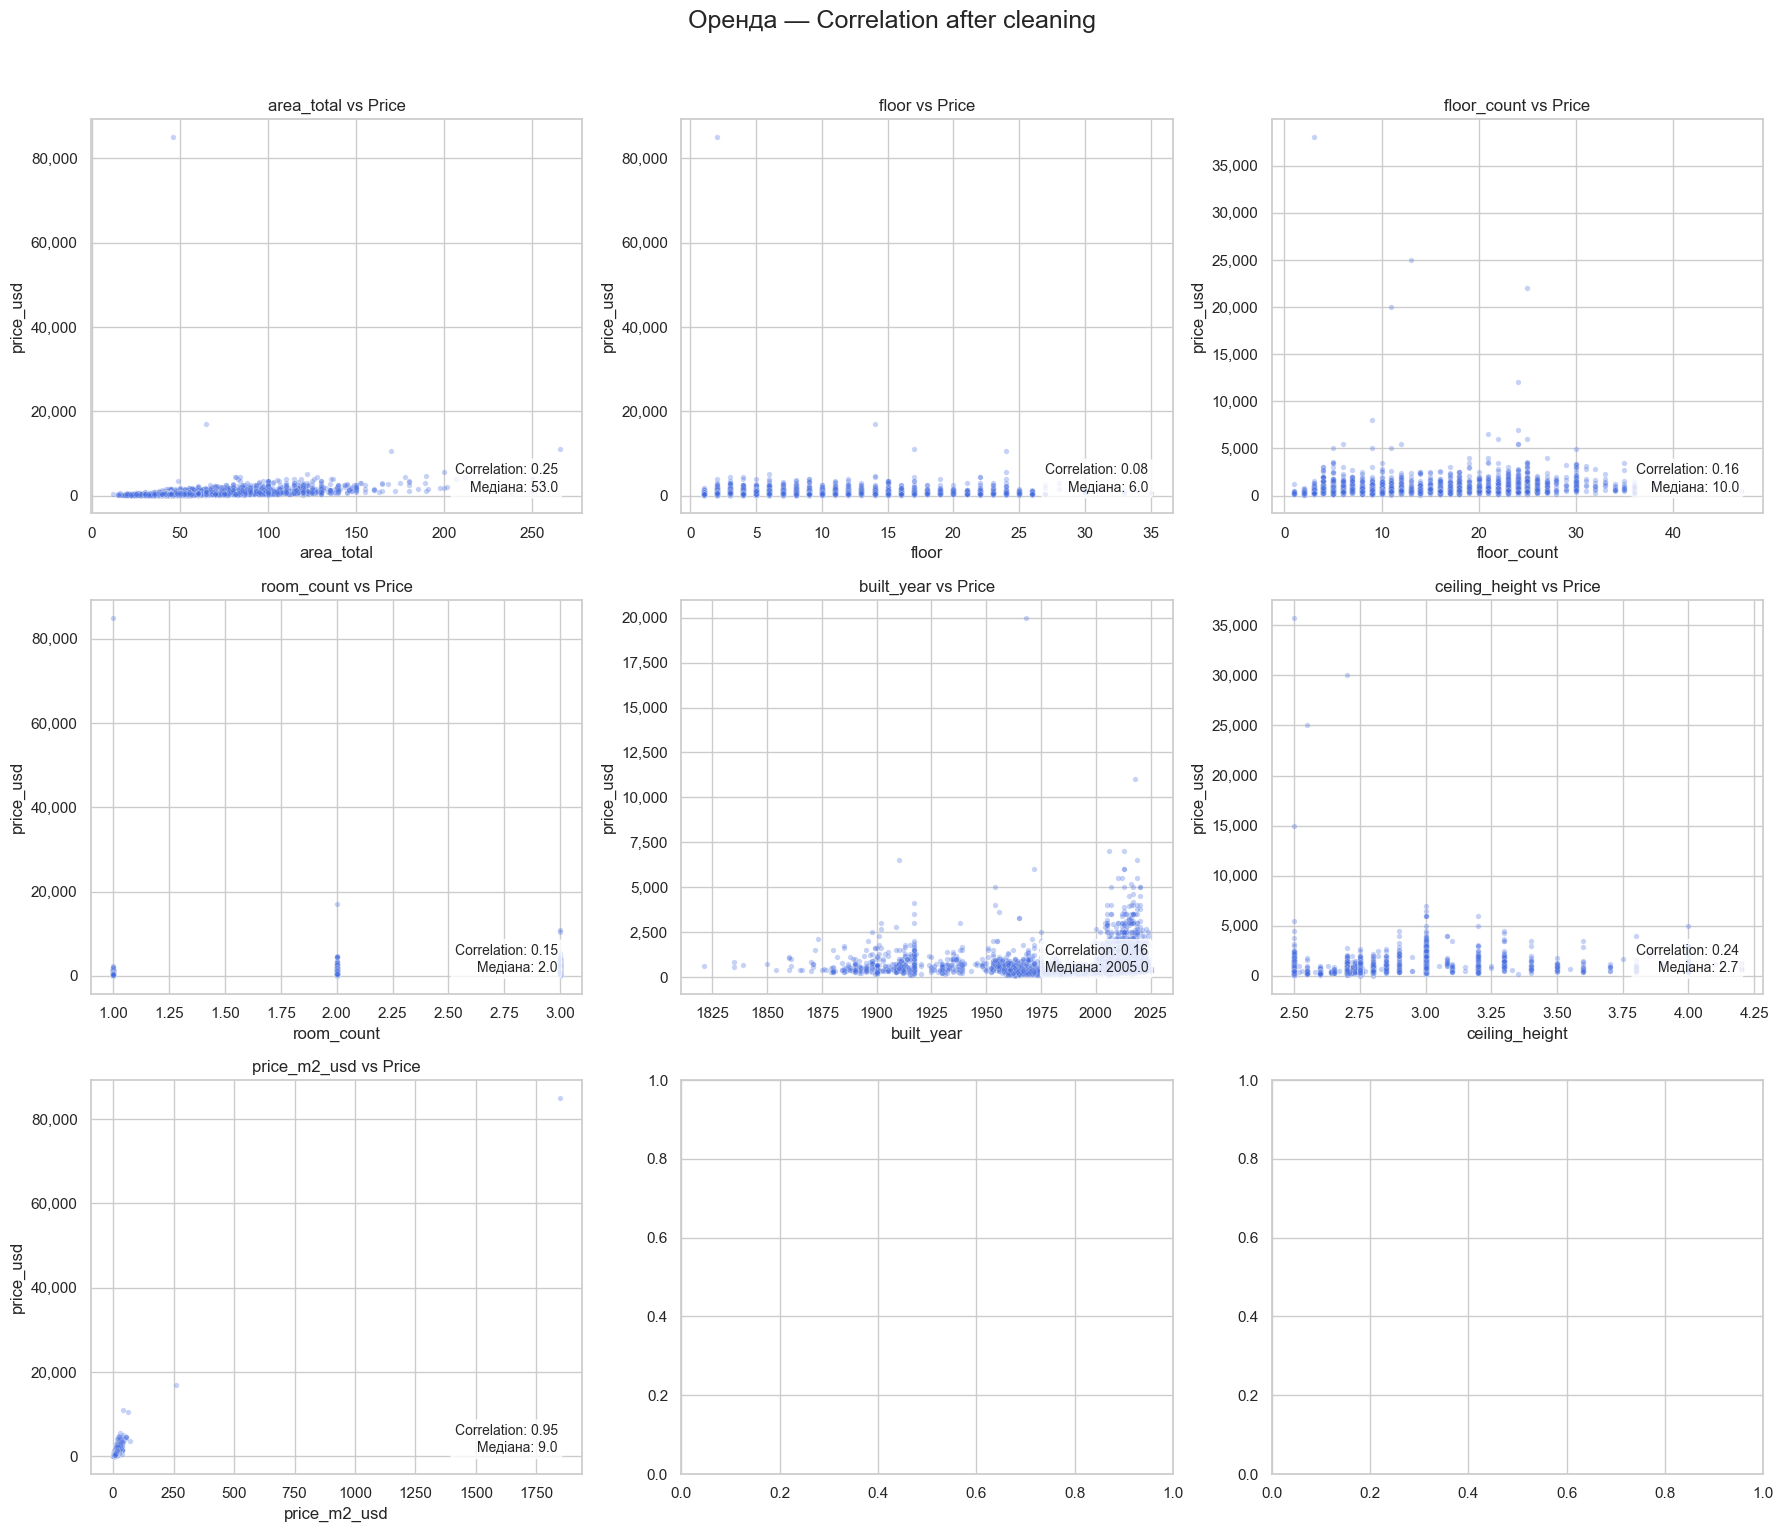

In [30]:
for contract in ['Продаж', 'Оренда']:
    df_sub = data[data['contract_type'] == contract].copy()
    n_rows = (len(cols_scatter) + 2) // 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows * 5))
    axes = axes.flatten()
    fig.suptitle(f'{contract} — Correlation after cleaning', fontsize=18, y=1.02)
    
    for i, col in enumerate(cols_scatter):
        ax = axes[i]
        sample_df = df_sub[['price_usd', col]].dropna()
        n_sample = min(5000, len(sample_df))
        
        if n_sample > 0:
            sample = sample_df.sample(n_sample, random_state=42)
            sns.scatterplot(data=sample, x=col, y='price_usd', alpha=0.3, s=15, color='royalblue', ax=ax)
            ax.set_title(f'{col} vs Price')
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

            stats_text = f"Correlation: {sample[col].corr(sample['price_usd']):.2f}\nМедіана: {sample[col].median():.1f}"
            ax.text(0.95, 0.05, stats_text, transform=ax.transAxes, fontsize=10, 
                    va='bottom', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        else:
            ax.set_visible(False)
            
    plt.tight_layout()
    plt.show()

# Missing values/Feature engineering 

In [31]:
missing_values = data.isna().sum()
print(missing_values[missing_values > 0].sort_values(ascending=False))

area_land                 933382
agency                    904355
is_babushka_renovation    848489
autonomy_water            607005
has_gas                   607005
autonomy_heat             607005
autonomy_power            607005
autonomy_net              607005
autonomy_lift             607005
pets_allowed_full         607005
area_living               519443
house_type                476641
built_year                461954
ceiling_height            414267
house_number              355496
wall_type                 304761
heating_system            286594
microdistrict             258308
street                    252699
latitude                  207250
longitude                 207250
page_id                   181709
price                     181709
region                    181709
district                   55391
area_kitchen               35648
floor_count                  930
dtype: int64


## Categorical feature

### Making, or is binary

Fill with 0 since it's positive features mostly and if it is not 1 probably is not there

In [32]:
war_features = ['autonomy_power', 'autonomy_heat', 'autonomy_water', 'autonomy_lift', 'autonomy_net', 'has_gas', 'is_near_subway']
data[war_features] = data[war_features].fillna(0)

In [33]:
zero_fill_cols = ['is_babushka_renovation', 'pets_allowed_full', 'has_parking']
data[zero_fill_cols] = data[zero_fill_cols].fillna(0)

### Categorical

In [34]:
data['heating_system'].unique()

array(['автономне опалення', 'індивідуальне опалення',
       'централізоване опалення', nan], dtype=object)

In [35]:
cat_features = ['wall_type', 'house_type']
data[cat_features] = data[cat_features].fillna('Unknown')

## District microdistrict fill

In [36]:
print("Has coordinates but not district:")
print(data[data['latitude'].notnull() & data['district'].isnull() & data['microdistrict'].isnull()].shape[0])

print("\nHas street but not district:")
print(data[data['street'].notnull() & data['district'].isnull() & data['microdistrict'].isnull()].shape[0])

print("\nNo coordinates no street and no district:")
print(data[
    data['latitude'].isnull() & 
    data['street'].isnull() & 
    data['district'].isnull() & data['microdistrict'].isnull()
].shape[0])


Has coordinates but not district:
41991

Has street but not district:
33370

No coordinates no street and no district:
5311


In [37]:
no_location_data = data[data['microdistrict'].isna() & data['district'].isna()]
no_location_data_ent = len(no_location_data)

print(f"Number of rows with no more specific information about location other than district: {no_location_data_ent}")
print(f"Percentage of rows with no more specified information about location other than district: {((len(data[data['microdistrict'].isna()])- no_location_data_ent)/1016117)*100}%")

Number of rows with no more specific information about location other than district: 47466
Percentage of rows with no more specified information about location other than district: 20.74977586242529%


In [38]:
def fill_district_by_micro(df, city):
    mask_city = df['city'] == city
    
    micro_to_district = (
        df[mask_city & df['microdistrict'].notna() & df['district'].notna()]
        .groupby('microdistrict')['district']
        .agg(lambda x: x.mode()[0])
        .to_dict()
    )
    
    mask_need = (mask_city & df['microdistrict'].notna() & df['district'].isnull())
    
    df.loc[mask_need, 'district'] = (
        df.loc[mask_need, 'microdistrict'].map(micro_to_district)
    )
    
    print(f"  By microdistrict → district: {mask_need.sum():,}")
    return df


def fill_district_by_street(df, city):
    mask_city = df['city'] == city
    
    street_to_district = (
        df[mask_city & df['street'].notna() & df['district'].notna()]
        .groupby('street')['district']
        .agg(lambda x: x.mode()[0])
        .to_dict()
    )
    
    mask_need = (mask_city & df['street'].notna() & df['district'].isnull())
    
    df.loc[mask_need, 'district'] = (
        df.loc[mask_need, 'street'].map(street_to_district)
    )
    
    print(f"  By street → district: {mask_need.sum():,}")
    return df


def fill_district_by_coords(df, city):
    mask_city = df['city'] == city
    
    donors = df[mask_city & 
                df['latitude'].notna() & 
                df['longitude'].notna() & 
                df['district'].notna()].copy()
    
    recipients = df[mask_city & 
                    df['latitude'].notna() & 
                    df['longitude'].notna() & 
                    df['district'].isnull()].copy()
    
    print(f"  By coords → district: {len(recipients):,}")
    
    if len(donors) == 0 or len(recipients) == 0:
        return df
    
    tree = BallTree(np.radians(donors[['latitude', 'longitude']].values), 
                    metric='haversine')
    _, indices = tree.query(np.radians(recipients[['latitude', 'longitude']].values), k=1)
    
    df.loc[recipients.index, 'district'] = (
        donors.iloc[indices.flatten()]['district'].values
    )
    
    return df


def fill_micro_by_street(df, city):
    mask_city = df['city'] == city
    
    street_to_micro = (
        df[mask_city & df['street'].notna() & df['microdistrict'].notna()]
        .groupby('street')['microdistrict']
        .agg(lambda x: x.mode()[0])
        .to_dict()
    )
    
    mask_need = (mask_city & 
                 df['street'].notna() & 
                 df['district'].notna() & 
                 df['microdistrict'].isnull())
    
    df.loc[mask_need, 'microdistrict'] = (
        df.loc[mask_need, 'street'].map(street_to_micro)
    )
    
    print(f"  By street → microdistrict: {mask_need.sum():,}")
    return df


def fill_micro_by_coords(df, city):
    mask_city = df['city'] == city
    
    donors = df[mask_city & 
                df['latitude'].notna() & 
                df['longitude'].notna() & 
                df['microdistrict'].notna()].copy()
    
    recipients = df[mask_city & 
                    df['latitude'].notna() & 
                    df['longitude'].notna() & 
                    df['district'].notna() &
                    df['microdistrict'].isnull()].copy()
    
    print(f"  By coords → microdistrict: {len(recipients):,}")
    
    if len(donors) == 0 or len(recipients) == 0:
        return df
    
    tree = BallTree(np.radians(donors[['latitude', 'longitude']].values), 
                    metric='haversine')
    _, indices = tree.query(np.radians(recipients[['latitude', 'longitude']].values), k=1)
    
    df.loc[recipients.index, 'microdistrict'] = (
        donors.iloc[indices.flatten()]['microdistrict'].values
    )
    
    return df



def fill_micro_by_district_housetype(df, city):
    mask_city = df['city'] == city

    district_housetype_to_micro = (
        df[mask_city & 
           df['district'].notna() & 
           df['house_type'].notna() & 
           df['microdistrict'].notna()]
        .groupby(['district', 'house_type'])['microdistrict']
        .agg(lambda x: x.mode()[0])
        .to_dict()
    )
    
    district_to_micro = (
        df[mask_city & df['district'].notna() & df['microdistrict'].notna()]
        .groupby('district')['microdistrict']
        .agg(lambda x: x.mode()[0])
        .to_dict()
    )
    
    mask_need = (mask_city & df['district'].notna() & df['microdistrict'].isnull())
    
    def get_micro(row):
        key = (row['district'], row['house_type'])
        if key in district_housetype_to_micro:
            return district_housetype_to_micro[key]
        return district_to_micro.get(row['district'], np.nan)
    
    df.loc[mask_need, 'microdistrict'] = (
        df.loc[mask_need].apply(get_micro, axis=1)
    )
    
    print(f"  By district+house_type → microdistrict: {mask_need.sum():,}")
    return df

print("="*50)
print("BEFORE imputation:")
print(f"  district null:      {data['district'].isnull().sum():,}")
print(f"  microdistrict null: {data['microdistrict'].isnull().sum():,}")

for city in ['Київ', 'Львів']:
    print(f"\n{'='*50}")
    print(f"Processing: {city}")
    
    data = fill_district_by_micro(data, city)
    data = fill_district_by_street(data, city)
    data = fill_district_by_coords(data, city)
    
    data = fill_micro_by_street(data, city)
    data = fill_micro_by_coords(data, city)
    data = fill_micro_by_district_housetype(data, city)

print(f"\n{'='*50}")
print("AFTER imputation:")
print(f"  district null:      {data['district'].isnull().sum():,}")
print(f"  microdistrict null: {data['microdistrict'].isnull().sum():,}")

mask_drop = (data['district'].isnull() & 
             data['microdistrict'].isnull() & 
             data['street'].isnull() & 
             data['latitude'].isnull() & 
             data['longitude'].isnull())

print(f"\nВDeleting with no more information than district: {mask_drop.sum():,}")
data = data[~mask_drop].copy().reset_index(drop=True)
print(f"Left: {len(data):,}")

print("\nDistricts by citites:")
print(data.groupby('city')['district'].nunique())


BEFORE imputation:
  district null:      55,391
  microdistrict null: 258,308

Processing: Київ
  By microdistrict → district: 7,696
  By street → district: 27,120
  By coords → district: 3,163
  By street → microdistrict: 80,174
  By coords → microdistrict: 30,805
  By district+house_type → microdistrict: 39,168

Processing: Львів
  By microdistrict → district: 229
  By street → district: 6,250
  By coords → district: 5,697
  By street → microdistrict: 68,012
  By coords → microdistrict: 15,349
  By district+house_type → microdistrict: 28,604

AFTER imputation:
  district null:      5,314
  microdistrict null: 5,314

ВDeleting with no more information than district: 5,311
Left: 928,086

Districts by citites:
city
Київ     10
Львів     6
Name: district, dtype: int64


In [39]:
print(data['district'].isna().sum())

3


In [40]:
print()

lviv_data = data[data['city'] == 'Київ']

print("--- Kyiv districts ---")
print(lviv_data['district'].dropna().unique())

print("\n--- Kyiv microdistricts ---")
print(lviv_data['microdistrict'].dropna().unique())


--- Kyiv districts ---
['Печерський' 'Шевченківський' 'Святошинський' 'Дніпровський'
 'Оболонський' 'Дарницький' 'Подільський' 'Голосіївський' "Солом'янський"
 'Деснянський']

--- Kyiv microdistricts ---
['Липки' 'Історичний центр' 'Печерськ' 'Чорна Гора' 'Нова забудова'
 'Борщагівка' 'Черепанова гора' 'Лівобережний масив' 'Оболонь' 'Райдужний'
 'Позняки' 'Мостицький масив' "Лук'янівка" 'Теремки-2' 'Святошин'
 'Шулявка' 'Нижній Печерськ' 'Нова Дарниця' 'Первомайський масив'
 'Північно-Броварський (Комсомольський)' 'Осокорки' 'Сирець'
 'Солдатська слобідка' 'Кудрявець' 'Старий Київ' 'Виноградар' 'Мінський'
 'Лісовий' 'Берковець' 'Голосіїв' 'Рибальський острів' 'Куренівка'
 'Русанівка' 'Чоколівка' 'Троєщина' 'Біличі' 'Березняки' 'Поділ' 'Нивки'
 'Вітряні Гори' 'Олександрівська Слобідка' 'Верхня Теличка' 'Соцмісто'
 'Село Шевченка' 'КПІ' "Солом'янка" 'Вишгородський масив' 'Новобіличі'
 'Звіринець' 'Воскресенка' 'Деміївка' 'Саперна Слобідка' 'Замковище'
 'Відрадний' 'Караваєві Дачі' 'Харк

In [41]:
data.dropna(subset=['district'], inplace=True)

In [42]:
print(data['microdistrict'].isna().sum())

0


### Other fill

In [43]:
data['built_year'] = data.groupby(['district', 'house_type'])['built_year'].transform(lambda x: x.fillna(x.median()))

data['built_year'] = data.groupby('district')['built_year'].transform(lambda x: x.fillna(x.median()))

remaining_nan_pct = (data['built_year'].isna().sum() / len(data)) * 100
print(f"Left missing values: {remaining_nan_pct:.2f}%")

print((len(data[data['built_year'].isna()])/1016117)*100)

Left missing values: 0.00%
0.0


In [44]:
data['ceiling_height'] = data.groupby('house_type')['ceiling_height'].transform(lambda x: x.fillna(x.median()))

data['ceiling_height'] = data['ceiling_height'].fillna(2.7)

In [45]:
data['heat_individual'] = (data['heating_system'] == 'індивідуальне опалення').astype(int)
data['heat_autonomous'] = (data['heating_system'] == 'автономне опалення').astype(int)
data['heat_unknown']    = data['heating_system'].isnull().astype(int)

print(data[['heat_individual', 'heat_autonomous', 'heat_unknown']].sum())
print(f"\nSum of all categories = number of rows: {data[['heat_individual', 'heat_autonomous', 'heat_unknown']].sum().sum() + (data['heating_system'] == 'централізоване опалення').sum()}")

heat_individual    134615
heat_autonomous     67658
heat_unknown       283632
dtype: int64

Sum of all categories = number of rows: 928083


In [46]:
data.dropna(subset=['area_total'], inplace=True)

In [47]:
data.dropna(subset=['floor_count'], inplace=True)
data.dropna(subset=['floor'], inplace=True)

In [48]:
def parse_subway_json(val):
    if pd.isna(val) or val == '{}':
        return {}
    try:
        return json.loads(val.replace("'", '"'))
    except:
        return {}

subway_df = data['has_subway_in_radius'].apply(parse_subway_json).apply(pd.Series)

subway_df = subway_df.add_prefix('subway_').add_suffix('m')

subway_df = subway_df.replace({'yes': 1, 'no': 0}).fillna(0).astype(int)

data = pd.concat([data, subway_df], axis=1)
data.drop(columns=['has_subway_in_radius'], inplace=True)


bool_cols = [
    'are_coordinates_exact', 'is_near_subway', 'is_without_renovation', 
    'has_eoselia', 'has_furniture', 'has_balcony', 'has_parking', 
    'is_not_last_floor', 'is_owner', 'has_gas', 'autonomy_power', 
    'autonomy_heat', 'autonomy_water', 'autonomy_net', 'autonomy_lift', 
    'is_babushka_renovation', 'pets_allowed_full'
]

bool_mapping = {'yes': 1, 'some': 1, 'no': 0, 'unknown': 0, 0: 0, 1: 1}

for col in bool_cols:
    if col in data.columns:
        data[col] = data[col].astype(str).str.lower().map(bool_mapping).fillna(0).astype(int)


cat_cols = ['wall_type', 'house_type']
data = pd.get_dummies(data, columns=[c for c in cat_cols if c in data.columns], drop_first=True, dtype=int)


In [49]:
print(100*len(data)/1016117)

91.24510268010475


In [50]:
missing_values = data.isna().sum()
print(missing_values[missing_values > 0].sort_values(ascending=False))

area_land         927142
agency            898116
area_living       514055
house_number      349562
heating_system    283439
street            246777
latitude          201328
longitude         201328
page_id           176938
region            176938
price             176938
area_kitchen       34728
dtype: int64


# Add columns

In [52]:
strikes = pd.read_excel('snapshots_dates.xlsx')

data = data.merge(
    strikes.rename(columns={
        'snapshot_date': 'date',
        'n_strikes_kyiv': 'strikes_kyiv',
        'n_strikes_lviv': 'strikes_lviv'
    }),
    on='date',
    how='left'
)

data['n_strikes'] = data.apply(
    lambda row: row['strikes_kyiv'] if row['city'] == 'Київ' else row['strikes_lviv'],
    axis=1
)

data = data.drop(columns=['strikes_kyiv', 'strikes_lviv'])

print(data[['date', 'city', 'n_strikes']].drop_duplicates().sort_values(['city', 'date']))

             date   city  n_strikes
884356 2023-05-25   Київ         10
854341 2023-06-26   Київ         15
823416 2023-07-24   Київ          4
784933 2023-08-23   Київ          2
750219 2023-09-25   Київ          9
...           ...    ...        ...
103937 2025-09-24  Львів          3
76255  2025-10-24  Львів          2
49519  2025-11-24  Львів          3
23397  2025-12-24  Львів          5
99     2026-01-24  Львів          4

[66 rows x 3 columns]


In [53]:
data['log_price_usd'] = np.log(data['price_usd'])
data['log_price_m2_usd'] = np.log(data['price_m2_usd'])

In [54]:
url = "https://bank.gov.ua/NBU_Exchange/exchange_site?start=20230101&end=20260201&valcode=USD&sort=exchangedate&order=asc&json"
response = requests.get(url)
nbu_data = pd.DataFrame(response.json())
nbu_data['date'] = pd.to_datetime(nbu_data['exchangedate'], format='%d.%m.%Y')
nbu_data = nbu_data[['date', 'rate']].rename(columns={'rate': 'usd_rate'})

snapshot_dates = sorted(pd.to_datetime(data['date'].unique()))

snapshot_usd = []

for i, current_date in enumerate(snapshot_dates):
    prev_date = snapshot_dates[i - 1] if i > 0 else current_date - pd.Timedelta(days=30)
        
    mask = (nbu_data['date'] > prev_date) & (nbu_data['date'] <= current_date)
    snapshot_usd.append({
        'date': current_date,
        'usd_rate_avg': nbu_data.loc[mask, 'usd_rate'].mean()
    })

snapshot_usd_df = pd.DataFrame(snapshot_usd)
snapshot_usd_df['date'] = pd.to_datetime(snapshot_usd_df['date'])

data['date'] = pd.to_datetime(data['date'])

if 'usd_rate_avg' in data.columns:
    data = data.drop(columns=['usd_rate_avg'])

data = data.merge(snapshot_usd_df, on='date', how='left')

print(data[['date', 'usd_rate_avg']].drop_duplicates().sort_values('date'))

             date  usd_rate_avg
884356 2023-05-25     36.568600
854341 2023-06-26     36.568600
823416 2023-07-24     36.568600
784933 2023-08-23     36.568600
750219 2023-09-25     36.568600
735674 2023-11-01     36.519235
708015 2023-11-24     36.145530
680913 2023-12-24     36.764530
654096 2024-01-24     37.874777
627933 2024-02-24     37.846026
599652 2024-03-24     38.483097
570920 2024-04-24     39.272123
541090 2024-05-24     39.570917
510621 2024-06-24     40.407452
480256 2024-07-24     40.868037
450422 2024-08-24     41.163013
424535 2024-09-24     41.251368
398951 2024-10-24     41.228557
373304 2024-11-26     41.312203
348935 2024-12-24     41.687314
325656 2025-01-24     42.101439
297039 2025-02-24     41.735394
268753 2025-03-24     41.487464
240896 2025-04-24     41.390932
213763 2025-05-24     41.555087
186329 2025-06-24     41.562274
157989 2025-07-24     41.766997
131336 2025-08-24     41.546313
103934 2025-09-24     41.292994
76014  2025-10-24     41.506783
49386  2

# Statistical Validation

In [55]:
missing_values = data.isna().sum()
print(missing_values[missing_values > 0].sort_values(ascending=False))

area_land         927142
agency            898116
area_living       514055
house_number      349562
heating_system    283439
street            246777
latitude          201328
longitude         201328
page_id           176938
region            176938
price             176938
area_kitchen       34728
dtype: int64


In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 927157 entries, 0 to 927156
Data columns (total 96 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   page_id                          750219 non-null  float64       
 1   date                             927157 non-null  datetime64[ns]
 2   contract_type                    927157 non-null  object        
 3   realty_type                      927157 non-null  object        
 4   region                           750219 non-null  object        
 5   city                             927157 non-null  object        
 6   district                         927157 non-null  object        
 7   microdistrict                    927157 non-null  object        
 8   street                           680380 non-null  object        
 9   house_number                     577595 non-null  object        
 10  latitude                         725829 non-

In [57]:
print("--- INFO ---")
data.info()
print("\n--- COLUMNS ---")
print(data.columns.tolist())

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 927157 entries, 0 to 927156
Data columns (total 96 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   page_id                          750219 non-null  float64       
 1   date                             927157 non-null  datetime64[ns]
 2   contract_type                    927157 non-null  object        
 3   realty_type                      927157 non-null  object        
 4   region                           750219 non-null  object        
 5   city                             927157 non-null  object        
 6   district                         927157 non-null  object        
 7   microdistrict                    927157 non-null  object        
 8   street                           680380 non-null  object        
 9   house_number                     577595 non-null  object        
 10  latitude                       

# Split datasets 

In [58]:
lviv_rent = data[(data['city'] == 'Львів') & (data['contract_type'] == 'Оренда')].copy()
lviv_sale = data[(data['city'] == 'Львів') & (data['contract_type'] == 'Продаж')].copy()

kyiv_rent = data[(data['city'] == 'Київ') & (data['contract_type'] == 'Оренда')].copy()
kyiv_sale = data[(data['city'] == 'Київ') & (data['contract_type'] == 'Продаж')].copy()

print(f"Lviv rent: {lviv_rent.shape[0]} rows")
print(f"Lviv sale: {lviv_sale.shape[0]} rows")
print(f"Kyiv rent: {kyiv_rent.shape[0]} rows")
print(f"Kyiv sala: {kyiv_sale.shape[0]} rows")

Lviv rent: 117342 rows
Lviv sale: 133811 rows
Kyiv rent: 191439 rows
Kyiv sala: 484565 rows


In [59]:
cols_to_save = ['date', 'district', 'microdistrict', 'street', 'house_number', 
                'latitude', 'longitude', 'are_coordinates_exact', 'is_near_subway', 
                'price', 'currency', 'room_count', 'area_total', 
                'floor', 'floor_count', 'built_year', 'ceiling_height', 'heating_system', 'is_without_renovation', 
                'has_eoselia', 'has_furniture', 'has_balcony', 'has_parking',
                'is_owner', 'add_time', 'update_time', 'has_gas', 
                'autonomy_power', 'autonomy_heat', 'autonomy_water', 'autonomy_net', 
                'autonomy_lift', 'is_babushka_renovation', 'pets_allowed_full', 
                'price_uah', 'price_usd', 'price_m2_uah', 'price_m2_usd', 'publish_year', 
                'heat_individual', 'heat_autonomous', 'heat_unknown', 'subway_250m', 
                'subway_500m', 'subway_750m', 'subway_1000m', 'subway_1500m', 'subway_2000m', 
                'wall_type_блочний', 'wall_type_монолітно-каркасний', 'wall_type_панель', 
                'wall_type_утеплена панель', 'wall_type_цегла', 'house_type_АППС', 
                'house_type_АППС-люкс', 'house_type_БПС', 'house_type_австрійський будинок', 
                'house_type_гостинка', 'house_type_дореволюційний', 'house_type_малосімейка', 
                'house_type_польський будинок', 'house_type_польський люкс', 'house_type_радмін', 
                'house_type_серія 134', 'house_type_серія 447С', 'house_type_серія 464', 
                'house_type_серія 480А', 'house_type_серія 84', 'house_type_серія 87', 
                'house_type_серія 96', 'house_type_серія КП', 'house_type_серія КС', 
                'house_type_серія КТ', 'house_type_серія Т', 'house_type_спец. проект', 
                'house_type_сталінка', 'house_type_хрущовка', 'house_type_чеський проект', 
                'n_strikes', 'log_price_usd', 'log_price_m2_usd', 'usd_rate_avg', 'available']


lviv_rent[cols_to_save].to_csv('lviv_rent.csv', index=False)
lviv_sale[cols_to_save].to_csv('lviv_sale.csv', index=False)
kyiv_rent[cols_to_save].to_csv('kyiv_rent.csv', index=False)
kyiv_sale[cols_to_save].to_csv('kyiv_sale.csv', index=False)